# Structured pruning of ALMA-7B: final results

Every number, table and figure the report needs, computed from the files committed under
`results/`. Nothing here needs a GPU or the cluster.

- `results/full-2026-10-08/`: every system of the final grid on the complete test sets
  (WMT22, WMT21 for Icelandic), COMET-22, MetricX-24, BLEU, chrF++, 27 LoRA repairs.
- `results/grid-2026-10-06/`: the same grid on the first 300 segments per direction (the
  pilot), with the transfer matrices of all 180 specialists, the subnetwork masks, the
  seed-5678 replicate, the FLAP budget ablation and the SlimGPT fix canary.
- `results/pilot-2026-09-29/`: the earliest pilot, with the calibration-text experiment, 50
  percent pruning and the efficiency benchmark. It used the SlimGPT code before the fix of 6
  October.

**How significance is computed.** The macro scores (BLEU, chrF++, COMET, MetricX) are read
from `long.csv`. Every COMET and MetricX contrast is recomputed here from the per-segment
scores in `runs/*/scores.*.json`: a paired bootstrap stratified by direction, 1,000
resamples, seed 12345, the same procedure as `scripts/grid_report.py`. Section 1 checks
that the recomputed deltas, intervals and p-values match the ones the report script wrote.
BLEU significance cannot be recomputed here because the hypotheses are not in git (they
stay under `runs/` on the scur0560 account); BLEU contrasts are quoted from `results.json`.

Run from the repository root or from `notebooks/`. Needs numpy, pandas and matplotlib.
Tables and figures are also written to `results/paper/` (CSV, LaTeX, PDF, PNG).

In [1]:
from __future__ import annotations

import json
import math
import sys
from functools import cache
from pathlib import Path
from typing import ClassVar

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from mnlp_eval.languages import ALMA_PARALLEL_TRAIN_PAIRS  # noqa: E402
from mnlp_eval.prune.repair import RepairSpec  # noqa: E402

FULL = ROOT / "results" / "full-2026-10-08"
PILOT = ROOT / "results" / "grid-2026-10-06"
SEED2 = PILOT / "seed2"
EARLY = ROOT / "results" / "pilot-2026-09-29"
OUT = ROOT / "results" / "paper"
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "tables").mkdir(parents=True, exist_ok=True)

DIRECTIONS = (
    "cs-en",
    "de-en",
    "is-en",
    "ru-en",
    "zh-en",
    "en-cs",
    "en-de",
    "en-is",
    "en-ru",
    "en-zh",
)
INTO_EN = DIRECTIONS[:5]
OUT_OF_EN = DIRECTIONS[5:]
LANGS = ("cs", "de", "is", "ru", "zh")
METHODS = ("slimgpt", "flap")
CALIBS = ("ref", "gen")
SPARSITIES = (20, 30, 40)
SCOPES = ("multi", "pair", "dir")
METHOD_LABEL = {"slimgpt": "SlimGPT", "flap": "FLAP"}
CALIB_LABEL = {"ref": "reference", "gen": "generated"}
N_BOOT, BOOT_SEED = 1000, 12345

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

Plot style. Colours: SlimGPT blue, FLAP orange, dense grey. Scope is drawn as line style
and marker (multi solid circle, pair dashed square, direction dotted triangle), so the
figures also read in greyscale. Diverging maps run red (worse) through grey to blue
(better); overlap maps use one blue ramp.

In [2]:
INK, INK2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
COLOR = {"slimgpt": "#2a78d6", "flap": "#eb6834", "dense": "#52514e"}
SCOPE_STYLE = {"multi": ("-", "o"), "pair": ("--", "s"), "dir": (":", "^")}
DIVERGING = LinearSegmentedColormap.from_list("rg", ["#e34948", "#f0efec", "#2a78d6"])
SEQUENTIAL = LinearSegmentedColormap.from_list(
    "blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)

mpl.rcParams.update(
    {
        "figure.dpi": 72,
        "savefig.dpi": 200,
        "font.family": "sans-serif",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "axes.edgecolor": AXIS,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK2,
        "ytick.labelcolor": INK2,
        "legend.frameon": False,
        "lines.linewidth": 2,
        "lines.markersize": 6,
    }
)


def save(fig: plt.Figure, name: str) -> None:
    """Write a figure as PDF (for LaTeX) and PNG to results/paper/figures/."""
    for ext in ("pdf", "png"):
        fig.savefig(OUT / "figures" / f"{name}.{ext}", bbox_inches="tight")


def to_latex(df: pd.DataFrame, caption: str = "") -> str:
    """A booktabs tabular without pandas' jinja2 dependency."""
    cols = list(df.columns)
    lines = [
        "\\begin{tabular}{" + "l" * df.index.nlevels + "r" * len(cols) + "}",
        "\\toprule",
        " & ".join([*(n or "" for n in df.index.names), *map(str, cols)]).replace("%", "\\%")
        + " \\\\",
        "\\midrule",
    ]
    for idx, row in df.iterrows():
        keys = idx if isinstance(idx, tuple) else (idx,)
        cells = [*map(str, keys), *("" if pd.isna(v) else str(v) for v in row)]
        text = " & ".join(cells).replace("%", "\\%").replace("_", "\\_").replace("<", "$<$")
        lines.append(text + " \\\\")
    lines += ["\\bottomrule", "\\end{tabular}"]
    if caption:
        lines.insert(0, f"% {caption}")
    return "\n".join(lines) + "\n"


def export(df: pd.DataFrame, name: str, caption: str = "") -> pd.DataFrame:
    """Write a table as CSV and LaTeX to results/paper/tables/ and return it for display."""
    df.to_csv(OUT / "tables" / f"{name}.csv")
    (OUT / "tables" / f"{name}.tex").write_text(to_latex(df, caption))
    return df


def fmt_p(p: float) -> str:
    return "<0.001" if p < 0.001 else f"{p:.3f}"


def fmt_ci(lo: float, hi: float, digits: int = 4) -> str:
    return f"[{lo:+.{digits}f}, {hi:+.{digits}f}]"

## Loading

`long.csv` has one row per system and direction. `in_scope` marks the directions a model
was pruned for (all ten for multi, two for a pair model, one for a direction model);
out-of-scope rows exist only where a specialist was also scored on other directions (the
transfer matrices). `results.json` holds what `scripts/grid_report.py` computed, including
its bootstrap contrasts and the map from system name to run directory.

In [3]:
long_full = pd.read_csv(FULL / "long.csv")
long_pilot = pd.read_csv(PILOT / "long.csv")
long_seed2 = pd.read_csv(SEED2 / "long.csv")
res_full = json.loads((FULL / "results.json").read_text())
res_pilot = json.loads((PILOT / "results.json").read_text())
res_seed2 = json.loads((SEED2 / "results.json").read_text())

for name, frame in (("full", long_full), ("pilot", long_pilot), ("seed2", long_seed2)):
    print(f"{name}: {frame.system.nunique()} systems, {len(frame)} system x direction rows")


def non_english(direction: str) -> str:
    src, tgt = direction.split("-")
    return tgt if src == "en" else src


def system_name(
    method: str,
    calib: str,
    sparsity: int,
    scope: str,
    direction: str,
    *,
    lora: bool = False,
    prefix: str = "alma-7b",
) -> str:
    """The grid system that translates `direction` in a composite."""
    key = {"multi": "multi", "pair": f"pair-{non_english(direction)}", "dir": f"dir-{direction}"}[
        scope
    ]
    return f"{prefix}-{method}{sparsity}-{calib}-{key}" + ("-lora" if lora else "")


def composite(method, calib, sparsity, scope, *, lora=False, prefix="alma-7b", directions=None):
    """Direction -> system for a composite: one multi model, or each direction's specialist."""
    return {
        d: system_name(method, calib, sparsity, scope, d, lora=lora, prefix=prefix)
        for d in (directions or DIRECTIONS)
    }


DENSE = dict.fromkeys(DIRECTIONS, "alma-7b")


class Results:
    """Macro scores from long.csv and per-segment scores from runs/, for one evaluation."""

    GROUPS: ClassVar[dict[str, tuple[str, str]]] = {
        "comet": ("neural", "wmt22_comet_da"),
        "metricx": ("metricx", "metricx24"),
        "bleu": ("surface", "bleu"),
        "chrf": ("surface", "chrf2pp"),
    }

    def __init__(self, root: Path, long: pd.DataFrame, res: dict, extra_runs: dict | None = None):
        self.root = root
        self.long = long.set_index(["system", "direction"]).sort_index()
        self.runs = dict(res["runs"])
        self.runs.update(extra_runs or {})

    def score(self, system: str, direction: str, metric: str) -> float:
        try:
            return float(self.long.loc[(system, direction), metric])
        except KeyError:
            group, key = self.GROUPS[metric]
            entry = self._load(self.runs[system], group)[direction]
            return float(entry["metrics"][key]["score"])

    def macro(self, comp: dict[str, str], metric: str) -> float:
        return float(np.mean([self.score(s, d, metric) for d, s in comp.items()]))

    @cache  # noqa: B019
    def _load(self, slug: str, group: str) -> dict:
        path = self.root / "runs" / slug / f"scores.{group}.json"
        return json.loads(path.read_text())["directions"] if path.exists() else {}

    def _run_scores(self, system: str, direction: str, metric: str) -> np.ndarray:
        group, key = self.GROUPS[metric]
        entry = self._load(self.runs[system], group).get(direction)
        if entry is None:
            return np.array([])
        return np.asarray(entry["metrics"][key]["segment_scores"], dtype=np.float64)

    def segments(self, system: str, direction: str, metric: str) -> np.ndarray:
        return self._run_scores(system, direction, metric)


def find_runs(root: Path, names: list[str]) -> dict[str, str]:
    """System -> run directory for runs that results.json does not list (ablations)."""
    found = {}
    for path in sorted((root / "runs").iterdir()):
        name = path.name.split("__")[0]
        if name in names:
            found[name] = path.name
    return found


ablation_names = [f"alma-7b-flap{s}-{c}-multi-global" for s in SPARSITIES for c in CALIBS] + [
    "alma-7b-slimgpt20-ref-multi-oldcode"
]
FULLR = Results(FULL, long_full, res_full)
PILOTR = Results(PILOT, long_pilot, res_pilot, find_runs(PILOT, ablation_names))
SEED2R = Results(PILOT, long_seed2, res_seed2)

full: 220 systems, 2200 system x direction rows
pilot: 220 systems, 2200 system x direction rows
seed2: 49 systems, 490 system x direction rows


### The bootstrap

A copy of `macro_segment_bootstrap` in `scripts/grid_report.py`: each resample redraws
segment positions independently within each direction (the same positions for both
systems), takes the per-direction mean difference and averages directions with equal
weight. The delta therefore equals the difference of the macro columns. Two-sided p is
P(|d_b - d| >= |d|), add-one smoothed, so the smallest reportable p is 1/1001 = 0.000999.
The interval is the 2.5 and 97.5 percentiles of the resampled deltas.

In [4]:
def bootstrap(pairs, n_samples: int = N_BOOT, seed: int = BOOT_SEED) -> dict:
    observed = float(np.mean([b.mean() - a.mean() for a, b in pairs]))
    rng = np.random.default_rng(seed)
    deltas = np.zeros(n_samples)
    for a, b in pairs:
        idx = rng.integers(0, a.shape[0], size=(n_samples, a.shape[0]))
        deltas += b[idx].mean(axis=1) - a[idx].mean(axis=1)
    deltas /= len(pairs)
    p = (1 + int((np.abs(deltas - observed) >= abs(observed)).sum())) / (n_samples + 1)
    return {
        "delta": observed,
        "ci_lo": float(np.percentile(deltas, 2.5)),
        "ci_hi": float(np.percentile(deltas, 97.5)),
        "p": p,
    }


def contrast(R: Results, base: dict, system: dict, metric: str = "comet") -> dict:
    """System minus base on the macro of a per-segment metric, over the shared directions."""
    pairs = []
    for d in DIRECTIONS:
        if d in base and d in system:
            a = R.segments(base[d], d, metric)
            b = R.segments(system[d], d, metric)
            if len(a) and len(a) == len(b):
                pairs.append((a, b))
    out = bootstrap(pairs)
    out["base"] = float(np.mean([a.mean() for a, _ in pairs]))
    out["system"] = float(np.mean([b.mean() for _, b in pairs]))
    out["n_directions"] = len(pairs)
    out["n_segments"] = int(sum(len(a) for a, _ in pairs))
    return out


def holm(pvalues) -> np.ndarray:
    """Holm-Bonferroni adjusted p-values."""
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    adjusted = np.empty_like(p)
    running = 0.0
    for rank, i in enumerate(order):
        running = max(running, (len(p) - rank) * p[i])
        adjusted[i] = min(1.0, running)
    return adjusted

## 1. Setup

### Model, data, decoding and metrics

In [5]:
dense_rows = long_full[long_full.system == "alma-7b"].set_index("direction").loc[list(DIRECTIONS)]
pilot_dense = long_pilot[long_pilot.system == "alma-7b"].set_index("direction")
manifest = json.loads(
    (FULL / "runs" / res_full["runs"]["alma-7b-slimgpt40-gen-multi"] / "manifest.json").read_text()
)
decode = manifest["suite"]["decode"]
score_files = {
    g: json.loads((FULL / "runs" / res_full["runs"]["alma-7b"] / f"scores.{g}.json").read_text())
    for g in ("surface", "neural", "metricx")
}

data_table = pd.DataFrame(
    {
        "test set": ["WMT21" if "is" in d else "WMT22" for d in DIRECTIONS],
        "test segments (full)": dense_rows.n_segments.astype(int).values,
        "test segments (pilot)": pilot_dense.loc[list(DIRECTIONS), "n_segments"].astype(int).values,
        "ALMA parallel training pairs": [
            ALMA_PARALLEL_TRAIN_PAIRS[non_english(d)] for d in DIRECTIONS
        ],
    },
    index=pd.Index(DIRECTIONS, name="direction"),
)
display(export(data_table, "data", "Test and training data per direction"))
print("total test segments:", int(dense_rows.n_segments.sum()), "full,", 300 * 10, "pilot")
print(
    "dataset:",
    manifest["suite"]["data"]["dataset"],
    "| decoding:",
    manifest["decode_summary"],
    "| batch",
    decode["batch_size"],
    "| max source length",
    decode["max_source_length"],
)
print("model:", manifest["model"]["model_name_or_path"], manifest["model"]["dtype"])
print("COMET:", score_files["neural"]["settings"]["comet_models"])
surface_dirs = score_files["surface"]["directions"]
for d in ("en-cs", "en-zh"):
    print(f"sacrebleu signatures, {d}:")
    print("  BLEU  ", surface_dirs[d]["metrics"]["bleu"]["signature"])
    print("  chrF++", surface_dirs[d]["metrics"]["chrf2pp"]["signature"])
print(
    "MetricX:",
    score_files["metricx"]["settings"]["metricx_model"],
    "| sacrebleu",
    score_files["surface"]["packages"]["sacrebleu"],
    "| COMET package",
    score_files["neural"]["packages"]["unbabel-comet"],
)

,test set,test segments (full),test segments (pilot),ALMA parallel training pairs
direction,,,,
cs-en,WMT22,1448,300,12076
de-en,WMT22,1984,300,14211
is-en,WMT21,1000,300,2009
ru-en,WMT22,2016,300,15000
zh-en,WMT22,1875,300,15406
en-cs,WMT22,2037,300,12076
en-de,WMT22,2037,300,14211
en-is,WMT21,1000,300,2009
en-ru,WMT22,2037,300,15000


total test segments: 17471 full, 3000 pilot
dataset: haoranxu/WMT22-Test | decoding: greedy, max_new_tokens=256 | batch 16 | max source length 256
model: haoranxu/ALMA-7B bfloat16
COMET: ['Unbabel/wmt22-comet-da']
sacrebleu signatures, en-cs:
  BLEU   nrefs:1|case:mixed|eff:no|tok:13a|smooth:exp|version:2.6.0
  chrF++ nrefs:1|case:mixed|eff:yes|nc:6|nw:2|space:no|version:2.6.0
sacrebleu signatures, en-zh:
  BLEU   nrefs:1|case:mixed|eff:no|tok:zh|smooth:exp|version:2.6.0
  chrF++ nrefs:1|case:mixed|eff:yes|nc:6|nw:2|space:no|version:2.6.0
MetricX: google/metricx-24-hybrid-large-v2p6-bfloat16 | sacrebleu 2.6.0 | COMET package 2.2.7


### The grid

2 methods x 2 calibration texts x 3 sparsities x 16 subnetworks (1 multi, 5 pair, 10
direction) = 192 pruned models. Every model is calibrated on 1,280 segments of
ALMA-Human-Parallel (train split), drawn with seed 1234 after removing any source that
occurs in the test sets: 128 per direction for multi, 640 per direction pair (320 each
way), 1,280 for a direction model. Reference (`ref`) and generated (`gen`) calibration use
the same source sentences, followed by the human reference or by dense ALMA-7B's own greedy
translation, and both end with the end-of-sequence token.

- **SlimGPT**: per-layer least-squares refit of the surviving weights to the calibration
  activations (exact joint solve, greedy removal with re-scoring, attention before FFN),
  with the log-increase layer schedule from the paper (first layer at a quarter of the
  target).
- **FLAP**: fluctuation-based importance with its adaptive structure search (AL-AM) across
  layers and modules, and bias compensation of the mean removed output.
- Sparsity is the share of attention and MLP parameters removed. Heads and FFN channels are
  removed and the weights compacted, so the result is a smaller dense model.

In [6]:
grid_table = pd.DataFrame(
    [
        ("method", "SlimGPT (log-increase schedule), FLAP (AL-AM)"),
        ("calibration text", "prompt + reference; prompt + dense ALMA-7B greedy translation"),
        ("sparsity", "20, 30, 40 percent of attention and MLP parameters"),
        ("scope", "1 multi-directional, 5 pair (both directions), 10 direction subnetworks"),
        ("calibration size", "1,280 segments for every model, seed 1234"),
        ("pruned models", "192, plus 48 seed-5678 replicates (SlimGPT, ref)"),
        ("LoRA repairs", "27: 7 multi, 20 pair models on their own pair"),
    ],
    columns=["factor", "levels"],
).set_index("factor")
display(grid_table)

structure = pd.read_csv(FULL / "structure.csv")
params_total = res_full["structure"]["alma-7b-slimgpt40-gen-multi"]["params_total"]
param_table = (
    structure[structure.scope == "multi"]
    .groupby(["method", "sparsity"])[
        [
            "heads_removed_frac",
            "ffn_removed_frac",
            "params_removed_frac_layers",
            "params_removed_frac_all",
        ]
    ]
    .mean()
    .mul(100)
    .round(1)
)
param_table["params kept (B)"] = (
    (1 - param_table.params_removed_frac_all / 100) * params_total / 1e9
).round(2)
param_table.columns = [
    "heads removed %",
    "FFN channels removed %",
    "attn+MLP params removed %",
    "all params removed %",
    "params kept (B)",
]
print(f"dense ALMA-7B: {params_total:,} parameters")
display(export(param_table, "structure_by_method", "What each method removes, multi models"))

,levels
factor,
method,"SlimGPT (log-increase schedule), FLAP (AL-AM)"
calibration text,prompt + reference; prompt + dense ALMA-7B gre...
sparsity,"20, 30, 40 percent of attention and MLP parame..."
scope,"1 multi-directional, 5 pair (both directions),..."
calibration size,"1,280 segments for every model, seed 1234"
pruned models,"192, plus 48 seed-5678 replicates (SlimGPT, ref)"
LoRA repairs,"27: 7 multi, 20 pair models on their own pair"


dense ALMA-7B: 6,738,415,616 parameters


heads removed %  FFN channels removed %  attn+MLP params removed %  all params removed %  params kept (B)
method  sparsity                                                                                                           
flap    20                    2.8                    28.5                       20.0                  19.2             5.44
        30                   11.5                    39.2                       30.0                  28.8             4.80
        40                   27.5                    46.2                       40.0                  38.4             4.15
slimgpt 20                   20.2                    20.0                       20.1                  19.3             5.44
        30                   29.9                    30.0                       30.0                  28.8             4.80
        40                   39.8                    40.0                       39.9                  38.4             4.15

Both methods hit the same parameter budget but spend it differently: SlimGPT removes the
same share of heads and FFN channels, FLAP's AL-AM removes far more FFN channels than heads.
The specialists have the same budgets (`structure.csv` has every model).

### LoRA repair recipe

ALMA's own LoRA stage, the `RepairSpec` defaults below, on ALMA-Human-Parallel minus the
two training segments whose sources occur in WMT22 (`repair-multi-clean`). A multi model
trains on all ten directions; a pair model only on its own pair. 500 segments are held out
to check that the loss falls.

In [7]:
spec = {
    f: getattr(RepairSpec, f)
    for f in (
        "rank",
        "alpha",
        "dropout",
        "target_modules",
        "learning_rate",
        "weight_decay",
        "epochs",
        "batch_size",
        "gradient_accumulation",
        "warmup_ratio",
        "max_grad_norm",
        "max_length",
        "held_out",
    )
}
display(pd.Series(spec, name="value").to_frame())
effective_batch = spec["batch_size"] * spec["gradient_accumulation"]
pairs_total = sum(ALMA_PARALLEL_TRAIN_PAIRS.values())
steps = {"multi (all ten)": math.ceil((2 * pairs_total - 2 - spec["held_out"]) / effective_batch)}
steps.update(
    {
        f"pair {lang}": math.ceil((2 * n - spec["held_out"]) / effective_batch)
        for lang, n in ALMA_PARALLEL_TRAIN_PAIRS.items()
    }
)
print(f"effective batch {effective_batch} sequences; optimizer steps per repair:")
display(pd.Series(steps, name="steps").to_frame())

,value
rank,16
alpha,32
dropout,0.05
target_modules,all-linear
learning_rate,0.002
weight_decay,0.01
epochs,1
batch_size,8
gradient_accumulation,16
warmup_ratio,0.01


effective batch 128 sequences; optimizer steps per repair:


,steps
multi (all ten),914
pair cs,185
pair de,219
pair is,28
pair ru,231
pair zh,237


The step counts agree with the training logs (914 for a multi model, 28 for Icelandic, 237
for Chinese). A multi repair took 1 h 40 to 2 h on one A100.

### Compute

From the run reports: the pilot grid took 78 GPU-hours (about 11,400 SBU), the full
evaluation 58 GPU-hours (about 9,500 SBU), on Snellius A100 and H100 nodes. The 29 September
pilot used 14.6 GPU-hours. Dense ALMA-7B on the full test sets: 34 minutes on one A100.

### Check: the recomputed contrasts match the report script

Every contrast in `results.json` that has per-segment scores is recomputed here and
compared. Identical procedure and seed, so the differences should be zero up to rounding.

In [8]:
def check_against_report(R: Results, res: dict) -> pd.DataFrame:
    rows = []
    for h in res["headline"]:
        m, c, s = h["method"], h["calib"], h["sparsity"]
        for scope in ("pair", "dir"):
            for metric in ("comet", "metricx"):
                ref = h.get(f"{scope}_minus_multi_{metric}")
                if not ref or ref.get("p_value") is None:
                    continue
                mine = contrast(R, composite(m, c, s, "multi"), composite(m, c, s, scope), metric)
                rows.append(
                    {
                        "contrast": f"{m}{s}-{c} {scope}-multi {metric}",
                        "delta diff": abs(mine["delta"] - ref["delta"]),
                        "ci diff": max(
                            abs(mine["ci_lo"] - ref["bootstrap_ci_95"][0]),
                            abs(mine["ci_hi"] - ref["bootstrap_ci_95"][1]),
                        ),
                        "p diff": abs(mine["p"] - ref["p_value"]),
                    }
                )
    return pd.DataFrame(rows)


for label, R, res in (("full", FULLR, res_full), ("pilot", PILOTR, res_pilot)):
    chk = check_against_report(R, res)
    print(
        f"{label}: {len(chk)} contrasts, largest |delta| diff {chk['delta diff'].max():.1e}, "
        f"CI diff {chk['ci diff'].max():.1e}, p diff {chk['p diff'].max():.1e}"
    )

full: 48 contrasts, largest |delta| diff 5.0e-07, CI diff 4.7e-07, p diff 1.0e-09


pilot: 24 contrasts, largest |delta| diff 4.7e-07, CI diff 4.9e-07, p diff 3.6e-07


## 2. Main results on the full test sets

Macro over the ten directions (equal weight per direction). For pair and dir, each
direction is translated by its matching specialist. MetricX-24 is an error score: lower is
better.

In [9]:
def headline(
    R: Results,
    metrics=("comet", "metricx", "bleu", "chrf"),
    prefix="alma-7b",
    methods=METHODS,
    calibs=CALIBS,
) -> pd.DataFrame:
    rows = []
    for m in methods:
        for c in calibs:
            for s in SPARSITIES:
                for scope in SCOPES:
                    comp = composite(m, c, s, scope, prefix=prefix)
                    row = {"method": m, "calib": c, "sparsity": s, "scope": scope}
                    for metric in metrics:
                        row[metric] = R.macro(comp, metric)
                    rows.append(row)
    return pd.DataFrame(rows)


head_full = headline(FULLR)
head_pilot = headline(PILOTR, metrics=("comet", "bleu", "chrf"))
dense_full = {k: res_full["dense"][k] for k in ("comet", "metricx", "bleu", "chrf")}
dense_pilot = {k: res_pilot["dense"][k] for k in ("comet", "bleu", "chrf")}
print("dense ALMA-7B, full:", {k: round(v, 4) for k, v in dense_full.items()})
print("dense ALMA-7B, pilot:", {k: round(v, 4) for k, v in dense_pilot.items()})


def wide(df: pd.DataFrame, metric: str, digits: int) -> pd.DataFrame:
    out = df.pivot_table(index=["method", "calib", "sparsity"], columns="scope", values=metric)
    out = out[list(SCOPES)].round(digits)
    return out.reindex(
        pd.MultiIndex.from_product(
            [METHODS, CALIBS, SPARSITIES], names=["method", "calib", "sparsity"]
        )
    )


main_comet = wide(head_full, "comet", 4).add_prefix("COMET ")
main_bleu = wide(head_full, "bleu", 2).add_prefix("BLEU ")
main_mx = wide(head_full, "metricx", 3).add_prefix("MetricX ")
main_chrf = wide(head_full, "chrf", 2).add_prefix("chrF++ ")
main_table = pd.concat([main_comet, main_mx, main_bleu, main_chrf], axis=1)
display(export(main_table, "main_full", "Main table, full test sets"))

# Cross-check against the report's own headline numbers.
indexed = head_full.set_index(["method", "calib", "sparsity", "scope"])
diffs = [
    abs(indexed.loc[(h["method"], h["calib"], h["sparsity"], scope), k] - h[scope][k])
    for h in res_full["headline"]
    for scope in SCOPES
    for k in ("comet", "metricx", "bleu", "chrf")
]
print(f"largest difference from results.json headline: {max(diffs):.1e}")

dense ALMA-7B, full: {'comet': 0.8475, 'metricx': 2.9369, 'bleu': 30.3203, 'chrf': 51.1258}
dense ALMA-7B, pilot: {'comet': 0.8474, 'bleu': 30.3511, 'chrf': 51.139}


scope                   COMET multi  COMET pair  COMET dir  MetricX multi  MetricX pair  MetricX dir  BLEU multi  BLEU pair  BLEU dir  chrF++ multi  chrF++ pair  chrF++ dir
method  calib sparsity                                                                                                                                                      
slimgpt ref   20             0.8361      0.8383     0.8382          3.356         3.287        3.265       27.76      28.21     28.10         49.10        49.45       49.38
              30             0.8223      0.8285     0.8289          3.809         3.608        3.562       25.78      26.60     26.57         47.27        48.07       48.01
              40             0.7931      0.8088     0.8097          4.857         4.324        4.246       23.24      24.04     24.23         44.77        45.71       45.81
        gen   20             0.8359      0.8387     0.8382          3.345         3.258        3.274       27.91      28.27     28.19         49.19        49.59       49.44
              30             0.8227      0.8287     0.8282          3.815         3.614        3.578       25.94      26.78     26.81         47.53        48.26       48.17
              40             0.7937      0.8089     0.8096          4.866         4.303        4.278       23.27      24.33     24.44         44.79        45.83       46.05
flap    ref   20             0.8224      0.8300     0.8300          3.851         3.604        3.605       26.74      27.49     27.70         47.82        48.43       48.71
              30             0.7832      0.8017     0.8024          5.222         4.612        4.591       23.61      24.50     24.48         44.59        45.53       45.75
              40             0.7414      0.7596     0.7592          6.697         6.154        6.154       20.31      20.31     20.45         41.00        41.24       41.45
        gen   20             0.8217      0.8292     0.8305          3.884         3.640        3.593       26.72      27.44     27.73         47.81        48.41       48.80
              30             0.7823      0.8011     0.8014          5.231         4.641        4.604       23.55      24.46     24.52         44.56        45.49       45.70
              40             0.7417      0.7580     0.7577          6.665         6.175        6.179       20.17      20.34     20.54         40.85        41.31       41.53

largest difference from results.json headline: 5.0e-06


Compact version for the paper: COMET with BLEU, generated calibration only (the reference
arm is within 0.0015 COMET of every cell, section 5), with the repaired systems alongside.

In [10]:
def repaired_macro(R: Results, m, c, s, scope) -> tuple[float, float] | None:
    comp = composite(m, c, s, scope, lora=True)
    if not all(sys_ in R.runs for sys_ in comp.values()):
        return None
    return R.macro(comp, "comet"), R.macro(comp, "bleu")


compact = []
for m in METHODS:
    for s in SPARSITIES:
        for c in CALIBS:
            row = {"method": METHOD_LABEL[m], "removed": f"{s}%", "calibration": CALIB_LABEL[c]}
            for scope in SCOPES:
                r = head_full.query(
                    "method == @m and calib == @c and sparsity == @s and scope == @scope"
                ).iloc[0]
                row[scope] = f"{r.comet:.4f} ({r.bleu:.2f})"
            for scope in ("multi", "pair"):
                rep = repaired_macro(FULLR, m, c, s, scope)
                row[f"{scope} + LoRA"] = "" if rep is None else f"{rep[0]:.4f} ({rep[1]:.2f})"
            compact.append(row)
compact = pd.DataFrame(compact).set_index(["method", "removed", "calibration"])
display(export(compact, "main_compact", "COMET (BLEU), full test sets, with LoRA repairs"))

multi            pair             dir    multi + LoRA     pair + LoRA
method  removed calibration                                                                                
SlimGPT 20%     reference    0.8361 (27.76)  0.8383 (28.21)  0.8382 (28.10)  0.8391 (28.51)                
                generated    0.8359 (27.91)  0.8387 (28.27)  0.8382 (28.19)                                
        30%     reference    0.8223 (25.78)  0.8285 (26.60)  0.8289 (26.57)                                
                generated    0.8227 (25.94)  0.8287 (26.78)  0.8282 (26.81)  0.8312 (27.48)  0.8353 (28.04)
        40%     reference    0.7931 (23.24)  0.8088 (24.04)  0.8097 (24.23)  0.8195 (26.10)                
                generated    0.7937 (23.27)  0.8089 (24.33)  0.8096 (24.44)  0.8196 (26.16)  0.8248 (26.34)
FLAP    20%     reference    0.8224 (26.74)  0.8300 (27.49)  0.8300 (27.70)                                
                generated    0.8217 (26.72)  0.8292 (27.44)  0.8305 (27.73)                                
        30%     reference    0.7832 (23.61)  0.8017 (24.50)  0.8024 (24.48)                                
                generated    0.7823 (23.55)  0.8011 (24.46)  0.8014 (24.52)  0.8239 (27.05)  0.8261 (27.22)
        40%     reference    0.7414 (20.31)  0.7596 (20.31)  0.7592 (20.45)  0.8111 (25.72)                
                generated    0.7417 (20.17)  0.7580 (20.34)  0.7577 (20.54)  0.8113 (25.91)  0.8118 (25.38)

### Figure: quality against sparsity

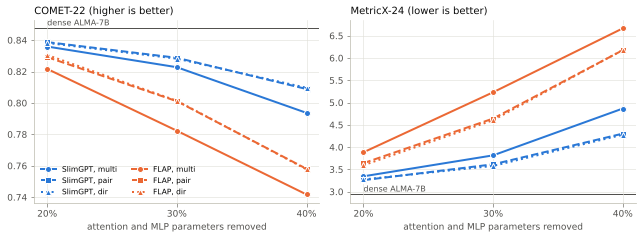

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharex=True)
for ax, metric, dense_value, label in (
    (axes[0], "comet", dense_full["comet"], "COMET-22 (higher is better)"),
    (axes[1], "metricx", dense_full["metricx"], "MetricX-24 (lower is better)"),
):
    ax.axhline(dense_value, color=COLOR["dense"], lw=1, ls="-", zorder=1)
    ax.annotate(
        "dense ALMA-7B",
        (20, dense_value),
        xytext=(0, 3),
        textcoords="offset points",
        color=INK2,
        fontsize=8,
    )
    for m in METHODS:
        for scope in SCOPES:
            sub = head_full.query(
                "method == @m and calib == 'gen' and scope == @scope"
            ).sort_values("sparsity")
            ls, marker = SCOPE_STYLE[scope]
            ax.plot(
                sub.sparsity,
                sub[metric],
                ls=ls,
                marker=marker,
                color=COLOR[m],
                label=f"{METHOD_LABEL[m]}, {scope}",
                markeredgecolor="white",
                markeredgewidth=1,
            )
    ax.set_xticks(SPARSITIES, [f"{s}%" for s in SPARSITIES])
    ax.set_xlabel("attention and MLP parameters removed")
    ax.set_title(label, loc="left")
axes[0].legend(ncol=2, fontsize=7.5, loc="lower left")
fig.tight_layout()
save(fig, "quality_vs_sparsity")
plt.show()

Generated calibration shown; the reference arm overlaps it everywhere. In the repair figure
below, the grey line is dense ALMA-7B.

## 3. SlimGPT against FLAP

SlimGPT minus FLAP at matched calibration, sparsity and scope. Positive COMET delta and
negative MetricX delta favour SlimGPT. BLEU deltas are quoted from the report script.

In [12]:
def method_contrasts(R: Results, res: dict, metrics=("comet", "metricx")) -> pd.DataFrame:
    bleu_lookup = {
        (e["baseline"]["calib"], e["baseline"]["sparsity"], e["baseline"]["scope"]): e.get("bleu")
        for e in res["slimgpt_vs_flap"]
    }
    rows = []
    for c in CALIBS:
        for s in SPARSITIES:
            for scope in SCOPES:
                row = {"calib": c, "sparsity": s, "scope": scope}
                for metric in metrics:
                    r = contrast(
                        R, composite("flap", c, s, scope), composite("slimgpt", c, s, scope), metric
                    )
                    digits = 4 if metric == "comet" else 3
                    row[f"{metric} delta"] = round(r["delta"], digits)
                    row[f"{metric} 95% CI"] = fmt_ci(r["ci_lo"], r["ci_hi"], digits)
                    row[f"{metric} p"] = fmt_p(r["p"])
                b = bleu_lookup.get((c, s, scope))
                if b and b.get("delta") is not None:
                    row["BLEU delta"] = round(b["delta"], 2)
                    row["BLEU p"] = fmt_p(b["p_value"]) if b.get("p_value") is not None else ""
                rows.append(row)
    return pd.DataFrame(rows).set_index(["calib", "sparsity", "scope"])


method_full = method_contrasts(FULLR, res_full)
display(export(method_full, "slimgpt_vs_flap_full", "SlimGPT minus FLAP, full test sets"))

comet delta        comet 95% CI comet p  metricx delta    metricx 95% CI metricx p  BLEU delta  BLEU p
calib sparsity scope                                                                                                        
ref   20       multi       0.0137  [+0.0125, +0.0148]  <0.001         -0.495  [-0.537, -0.452]    <0.001        1.02  <0.001
               pair        0.0083  [+0.0072, +0.0093]  <0.001         -0.318  [-0.359, -0.277]    <0.001        0.73  <0.001
               dir         0.0082  [+0.0072, +0.0092]  <0.001         -0.340  [-0.382, -0.300]    <0.001        0.40  <0.001
      30       multi       0.0391  [+0.0375, +0.0407]  <0.001         -1.412  [-1.472, -1.351]    <0.001        2.17  <0.001
               pair        0.0267  [+0.0252, +0.0282]  <0.001         -1.004  [-1.057, -0.954]    <0.001        2.10  <0.001
               dir         0.0265  [+0.0252, +0.0279]  <0.001         -1.029  [-1.083, -0.976]    <0.001        2.09  <0.001
      40       multi       0.0518  [+0.0498, +0.0538]  <0.001         -1.840  [-1.906, -1.777]    <0.001        2.93  <0.001
               pair        0.0492  [+0.0476, +0.0511]  <0.001         -1.830  [-1.895, -1.770]    <0.001        3.74  <0.001
               dir         0.0505  [+0.0488, +0.0523]  <0.001         -1.908  [-1.970, -1.846]    <0.001        3.79  <0.001
gen   20       multi       0.0142  [+0.0131, +0.0153]  <0.001         -0.539  [-0.583, -0.496]    <0.001        1.20  <0.001
               pair        0.0095  [+0.0085, +0.0106]  <0.001         -0.381  [-0.423, -0.340]    <0.001        0.83  <0.001
               dir         0.0077  [+0.0066, +0.0086]  <0.001         -0.319  [-0.363, -0.279]    <0.001        0.46  <0.001
      30       multi       0.0404  [+0.0388, +0.0421]  <0.001         -1.416  [-1.477, -1.362]    <0.001        2.39  <0.001
               pair        0.0276  [+0.0262, +0.0290]  <0.001         -1.027  [-1.080, -0.978]    <0.001        2.33  <0.001
               dir         0.0268  [+0.0255, +0.0283]  <0.001         -1.026  [-1.078, -0.976]    <0.001        2.28  <0.001
      40       multi       0.0519  [+0.0501, +0.0539]  <0.001         -1.799  [-1.865, -1.733]    <0.001        3.10  <0.001
               pair        0.0508  [+0.0492, +0.0526]  <0.001         -1.873  [-1.937, -1.807]    <0.001        3.99  <0.001
               dir         0.0519  [+0.0501, +0.0538]  <0.001         -1.901  [-1.966, -1.840]    <0.001        3.91  <0.001

Mechanism, for the discussion: SlimGPT refits the surviving weights to the calibration
activations, FLAP only adds back the mean of what it removed; the gap grows with sparsity
(+0.014 COMET at 20 percent, +0.052 at 40 for multi). Specialisation narrows the gap at 20
and 30 percent because it helps FLAP more.

## 4. One multi-directional subnetwork against specialists

Specialist composite minus the multi model, at equal calibration size (1,280 segments).
2 methods x 2 calibration texts x 3 sparsities x {pair, dir} x 2 metrics = 48 contrasts.

In [13]:
spec_rows = []
for m in METHODS:
    for c in CALIBS:
        for s in SPARSITIES:
            for scope in ("pair", "dir"):
                row = {"method": m, "calib": c, "sparsity": s, "scope": scope}
                for metric in ("comet", "metricx"):
                    r = contrast(
                        FULLR, composite(m, c, s, "multi"), composite(m, c, s, scope), metric
                    )
                    row[f"{metric} delta"] = r["delta"]
                    row[f"{metric} lo"] = r["ci_lo"]
                    row[f"{metric} hi"] = r["ci_hi"]
                    row[f"{metric} p"] = r["p"]
                spec_rows.append(row)
spec_full = pd.DataFrame(spec_rows)
favour = (spec_full["comet delta"] > 0).sum() + (spec_full["metricx delta"] < 0).sum()
print(f"contrasts favouring the specialists: {favour} of {2 * len(spec_full)}")
print(
    "largest p:",
    fmt_p(max(spec_full["comet p"].max(), spec_full["metricx p"].max())),
)

spec_view = spec_full.assign(
    **{
        "COMET delta": spec_full["comet delta"].round(4),
        "COMET 95% CI": [
            fmt_ci(a, b) for a, b in zip(spec_full["comet lo"], spec_full["comet hi"], strict=True)
        ],
        "MetricX delta": spec_full["metricx delta"].round(3),
        "MetricX 95% CI": [
            fmt_ci(a, b, 3)
            for a, b in zip(spec_full["metricx lo"], spec_full["metricx hi"], strict=True)
        ],
        "p (COMET / MetricX)": [
            f"{fmt_p(a)} / {fmt_p(b)}"
            for a, b in zip(spec_full["comet p"], spec_full["metricx p"], strict=True)
        ],
    }
)[
    [
        "method",
        "calib",
        "sparsity",
        "scope",
        "COMET delta",
        "COMET 95% CI",
        "MetricX delta",
        "MetricX 95% CI",
        "p (COMET / MetricX)",
    ]
]
display(
    export(
        spec_view.set_index(["method", "calib", "sparsity", "scope"]),
        "specialist_vs_multi_full",
        "Specialist minus multi, full test sets",
    )
)

contrasts favouring the specialists: 48 of 48
largest p: <0.001


COMET delta        COMET 95% CI  MetricX delta    MetricX 95% CI p (COMET / MetricX)
method  calib sparsity scope                                                                                      
slimgpt ref   20       pair        0.0022  [+0.0014, +0.0031]         -0.069  [-0.105, -0.032]     <0.001 / <0.001
                       dir         0.0021  [+0.0013, +0.0029]         -0.091  [-0.126, -0.052]     <0.001 / <0.001
              30       pair        0.0062  [+0.0052, +0.0073]         -0.202  [-0.241, -0.164]     <0.001 / <0.001
                       dir         0.0066  [+0.0056, +0.0076]         -0.248  [-0.289, -0.206]     <0.001 / <0.001
              40       pair        0.0156  [+0.0143, +0.0171]         -0.533  [-0.587, -0.478]     <0.001 / <0.001
                       dir         0.0166  [+0.0151, +0.0180]         -0.611  [-0.666, -0.554]     <0.001 / <0.001
        gen   20       pair        0.0028  [+0.0019, +0.0037]         -0.086  [-0.118, -0.050]     <0.001 / <0.001
                       dir         0.0023  [+0.0013, +0.0031]         -0.071  [-0.106, -0.034]     <0.001 / <0.001
              30       pair        0.0060  [+0.0050, +0.0070]         -0.201  [-0.243, -0.161]     <0.001 / <0.001
                       dir         0.0054  [+0.0044, +0.0065]         -0.237  [-0.275, -0.195]     <0.001 / <0.001
              40       pair        0.0152  [+0.0138, +0.0166]         -0.563  [-0.618, -0.508]     <0.001 / <0.001
                       dir         0.0160  [+0.0146, +0.0173]         -0.587  [-0.639, -0.533]     <0.001 / <0.001
flap    ref   20       pair        0.0076  [+0.0065, +0.0087]         -0.247  [-0.289, -0.202]     <0.001 / <0.001
                       dir         0.0076  [+0.0065, +0.0086]         -0.246  [-0.289, -0.200]     <0.001 / <0.001
              30       pair        0.0186  [+0.0169, +0.0202]         -0.610  [-0.668, -0.553]     <0.001 / <0.001
                       dir         0.0193  [+0.0175, +0.0209]         -0.631  [-0.687, -0.570]     <0.001 / <0.001
              40       pair        0.0182  [+0.0164, +0.0202]         -0.543  [-0.608, -0.481]     <0.001 / <0.001
                       dir         0.0178  [+0.0160, +0.0198]         -0.543  [-0.606, -0.479]     <0.001 / <0.001
        gen   20       pair        0.0075  [+0.0064, +0.0086]         -0.244  [-0.284, -0.198]     <0.001 / <0.001
                       dir         0.0089  [+0.0078, +0.0100]         -0.291  [-0.333, -0.244]     <0.001 / <0.001
              30       pair        0.0188  [+0.0171, +0.0205]         -0.590  [-0.648, -0.534]     <0.001 / <0.001
                       dir         0.0191  [+0.0174, +0.0206]         -0.627  [-0.682, -0.568]     <0.001 / <0.001
              40       pair        0.0163  [+0.0144, +0.0182]         -0.490  [-0.556, -0.426]     <0.001 / <0.001
                       dir         0.0160  [+0.0140, +0.0178]         -0.486  [-0.545, -0.421]     <0.001 / <0.001

Range of the gain per method and sparsity (both calibration texts, pair and dir):

In [14]:
display(
    spec_full.groupby(["method", "sparsity"])[["comet delta", "metricx delta"]]
    .agg(["min", "max"])
    .round(4)
)

comet delta         metricx delta        
                         min     max           min     max
method  sparsity                                          
flap    20            0.0075  0.0089       -0.2906 -0.2438
        30            0.0186  0.0193       -0.6313 -0.5900
        40            0.0160  0.0182       -0.5428 -0.4859
slimgpt 20            0.0021  0.0028       -0.0910 -0.0693
        30            0.0054  0.0066       -0.2479 -0.2011
        40            0.0152  0.0166       -0.6110 -0.5334

### Pair against direction subnetworks

Direction composite minus pair composite, Holm-corrected within each metric (12 contrasts).
Every COMET difference is within 0.0015. Two contrasts survive the correction, both small
and both favouring the direction models (FLAP gen 20% on COMET, SlimGPT ref 40% on
MetricX); the other 22 do not. In practice five pair models do the work of ten direction
models.

In [15]:
pd_rows = []
for m in METHODS:
    for c in CALIBS:
        for s in SPARSITIES:
            r = contrast(FULLR, composite(m, c, s, "pair"), composite(m, c, s, "dir"))
            rx = contrast(FULLR, composite(m, c, s, "pair"), composite(m, c, s, "dir"), "metricx")
            pd_rows.append(
                {
                    "method": m,
                    "calib": c,
                    "sparsity": s,
                    "COMET dir - pair": round(r["delta"], 4),
                    "95% CI": fmt_ci(r["ci_lo"], r["ci_hi"]),
                    "p": r["p"],
                    "MetricX dir - pair": round(rx["delta"], 3),
                    "MetricX p": rx["p"],
                }
            )
pair_dir = pd.DataFrame(pd_rows)
pair_dir["p Holm"] = holm(pair_dir.p)
pair_dir["MetricX p Holm"] = holm(pair_dir["MetricX p"])
print("largest |COMET dir - pair|:", pair_dir["COMET dir - pair"].abs().max())
print(
    "Holm-significant at 0.05: COMET",
    int((pair_dir["p Holm"] < 0.05).sum()),
    "of 12, MetricX",
    int((pair_dir["MetricX p Holm"] < 0.05).sum()),
    "of 12",
)
for col in ("p", "p Holm", "MetricX p", "MetricX p Holm"):
    pair_dir[col] = pair_dir[col].map(fmt_p)
display(
    export(
        pair_dir.set_index(["method", "calib", "sparsity"]),
        "dir_vs_pair_full",
        "Direction minus pair composites",
    )
)

largest |COMET dir - pair|: 0.0014
Holm-significant at 0.05: COMET 1 of 12, MetricX 1 of 12


COMET dir - pair              95% CI      p  MetricX dir - pair MetricX p p Holm MetricX p Holm
method  calib sparsity                                                                                                 
slimgpt ref   20                 -0.0001  [-0.0009, +0.0006]  0.739              -0.022     0.172  1.000          1.000
              30                  0.0004  [-0.0005, +0.0012]  0.355              -0.046     0.014  1.000          0.140
              40                  0.0009  [-0.0003, +0.0020]  0.116              -0.078     0.004  1.000          0.048
        gen   20                 -0.0005  [-0.0013, +0.0002]  0.171               0.016     0.316  1.000          1.000
              30                 -0.0005  [-0.0015, +0.0003]  0.207              -0.036     0.044  1.000          0.396
              40                  0.0008  [-0.0004, +0.0019]  0.190              -0.024     0.299  1.000          1.000
flap    ref   20                 -0.0000  [-0.0009, +0.0009]  0.987               0.001     0.949  1.000          1.000
              30                  0.0007  [-0.0007, +0.0020]  0.313              -0.021     0.423  1.000          1.000
              40                 -0.0004  [-0.0020, +0.0013]  0.665              -0.000     0.994  1.000          1.000
        gen   20                  0.0014  [+0.0005, +0.0023]  0.003              -0.047     0.010  0.036          0.110
              30                  0.0003  [-0.0012, +0.0015]  0.665              -0.037     0.138  1.000          1.000
              40                 -0.0004  [-0.0021, +0.0015]  0.691               0.004     0.900  1.000          1.000

## 5. Reference against generated calibration text

Generated minus reference, at matched method, sparsity and scope. 18 contrasts per metric;
Holm correction within each metric.

In [16]:
def ref_gen(R: Results, metrics=("comet", "metricx")) -> pd.DataFrame:
    rows = []
    for m in METHODS:
        for s in SPARSITIES:
            for scope in SCOPES:
                row = {"method": m, "sparsity": s, "scope": scope}
                for metric in metrics:
                    r = contrast(
                        R, composite(m, "ref", s, scope), composite(m, "gen", s, scope), metric
                    )
                    row[f"{metric} delta"] = r["delta"]
                    row[f"{metric} lo"] = r["ci_lo"]
                    row[f"{metric} hi"] = r["ci_hi"]
                    row[f"{metric} p"] = r["p"]
                rows.append(row)
    out = pd.DataFrame(rows)
    for metric in metrics:
        out[f"{metric} p Holm"] = holm(out[f"{metric} p"])
    return out


rg_full = ref_gen(FULLR)
print("largest |COMET gen - ref|:", round(rg_full["comet delta"].abs().max(), 4))
print(
    "nominal p < 0.05, COMET:",
    (rg_full["comet p"] < 0.05).sum(),
    "of 18; smallest p",
    round(rg_full["comet p"].min(), 3),
)
print("nominal p < 0.05, MetricX:", (rg_full["metricx p"] < 0.05).sum(), "of 18")
print(
    "Holm-significant:",
    int((rg_full["comet p Holm"] < 0.05).sum() + (rg_full["metricx p Holm"] < 0.05).sum()),
)
for m in METHODS:
    sub = rg_full[rg_full.method == m]
    print(
        f"{METHOD_LABEL[m]}: reference better in {(sub['comet delta'] < 0).sum()} of 9 COMET "
        "contrasts, "
        f"mean gen - ref {sub['comet delta'].mean():+.4f}"
    )
rg_view = (
    rg_full.assign(
        **{
            "COMET gen - ref": rg_full["comet delta"].round(4),
            "COMET 95% CI": [
                fmt_ci(a, b) for a, b in zip(rg_full["comet lo"], rg_full["comet hi"], strict=True)
            ],
            "COMET p": rg_full["comet p"].round(3),
            "COMET p Holm": rg_full["comet p Holm"].round(3),
            "MetricX gen - ref": rg_full["metricx delta"].round(3),
            "MetricX p": rg_full["metricx p"].round(3),
            "MetricX p Holm": rg_full["metricx p Holm"].round(3),
        }
    )
    .set_index(["method", "sparsity", "scope"])
    .iloc[:, -7:]
)
display(export(rg_view, "ref_vs_gen_full", "Generated minus reference calibration, full test sets"))

largest |COMET gen - ref|: 0.0015
nominal p < 0.05, COMET: 3 of 18; smallest p 0.034
nominal p < 0.05, MetricX: 3 of 18
Holm-significant: 0
SlimGPT: reference better in 3 of 9 COMET contrasts, mean gen - ref +0.0001
FLAP: reference better in 7 of 9 COMET contrasts, mean gen - ref -0.0007


COMET gen - ref        COMET 95% CI  COMET p  COMET p Holm  MetricX gen - ref  MetricX p  MetricX p Holm
method  sparsity scope                                                                                                          
slimgpt 20       multi          -0.0002  [-0.0008, +0.0005]    0.603         1.000             -0.011      0.421           1.000
                 pair            0.0004  [-0.0002, +0.0010]    0.193         1.000             -0.028      0.037           0.628
                 dir             0.0000  [-0.0006, +0.0006]    0.943         1.000              0.009      0.483           1.000
        30       multi           0.0004  [-0.0004, +0.0012]    0.335         1.000              0.006      0.747           1.000
                 pair            0.0002  [-0.0005, +0.0009]    0.519         1.000              0.006      0.690           1.000
                 dir            -0.0007  [-0.0014, +0.0000]    0.047         0.751              0.017      0.260           1.000
        40       multi           0.0005  [-0.0006, +0.0017]    0.358         1.000              0.009      0.716           1.000
                 pair            0.0001  [-0.0010, +0.0011]    0.867         1.000             -0.021      0.279           1.000
                 dir            -0.0001  [-0.0011, +0.0008]    0.930         1.000              0.032      0.115           1.000
flap    20       multi          -0.0007  [-0.0015, +0.0001]    0.073         0.965              0.033      0.049           0.783
                 pair           -0.0008  [-0.0016, -0.0001]    0.034         0.611              0.035      0.012           0.216
                 dir             0.0005  [-0.0002, +0.0012]    0.145         1.000             -0.012      0.402           1.000
        30       multi          -0.0009  [-0.0022, +0.0004]    0.183         1.000              0.009      0.695           1.000
                 pair           -0.0007  [-0.0017, +0.0004]    0.233         1.000              0.029      0.131           1.000
                 dir            -0.0011  [-0.0022, +0.0001]    0.069         0.965              0.014      0.516           1.000
        40       multi           0.0003  [-0.0011, +0.0020]    0.635         1.000             -0.032      0.197           1.000
                 pair           -0.0015  [-0.0030, -0.0001]    0.042         0.713              0.021      0.374           1.000
                 dir            -0.0015  [-0.0030, +0.0000]    0.052         0.779              0.025      0.303           1.000

What the two calibration texts look like: dense ALMA-7B's greedy translations of the
calibration sources against the human references (`calibration_diagnostics.json`). They
differ substantially, so the equivalence above is not because the two texts are the same.

In [17]:
diag = pd.DataFrame(json.loads((PILOT / "calibration_diagnostics.json").read_text()))
diag_dir = diag[diag.cache.str.startswith("dir-")].set_index("direction").loc[list(DIRECTIONS)]
display(
    export(
        diag_dir[["n", "chrf++", "bleu", "exact_match", "generated_tokens", "input_tokens"]],
        "calibration_generated_vs_reference",
        "Dense greedy translations of the calibration sources against the references",
    )
)

,n,chrf++,bleu,exact_match,generated_tokens,input_tokens
direction,,,,,,
cs-en,1280,60.20,37.68,0.0227,41159,86734
de-en,1280,65.97,45.12,0.0281,39958,74231
is-en,1280,62.26,41.42,0.0070,39069,103313
ru-en,1280,63.00,41.49,0.0148,39841,80221
zh-en,1280,56.15,30.71,0.0016,54217,116097
en-cs,1280,49.36,25.12,0.0094,65419,61552
en-de,1280,59.13,33.59,0.0133,55203,60911
en-is,1280,50.08,26.40,0.0055,76395,65584
en-ru,1280,54.92,32.39,0.0219,58717,59027


From the 29 September pilot (old SlimGPT code, 20 percent, multi, 300 segments): calibrating
on the prompt alone is far worse than on prompt plus reference, and doubling the prompt-only
calibration does not close the gap, so the gain comes from target-language text in the
input.

In [18]:
early = pd.read_csv(EARLY / "systems.csv").set_index("system")
display(
    export(
        early.loc[
            [
                "alma-7b",
                "alma-7b-slimgpt20-multi",
                "alma-7b-slimgpt20-multi-256",
                "alma-7b-slimgpt20-multi-target",
            ]
        ],
        "early_calibration_text",
        "29 September pilot: calibration text",
    )
)

,sparsity,calibration,bleu,chrf,comet,length_ratio,truncated_pct
system,,,,,,,
alma-7b,0.0,NaN,30.35,51.14,0.8474,0.964,0.0
alma-7b-slimgpt20-multi,0.2,"1,280 prompts",20.65,41.71,0.8148,0.909,0.1
alma-7b-slimgpt20-multi-256,0.2,"2,560 prompts",21.22,42.28,0.8195,0.904,0.2
alma-7b-slimgpt20-multi-target,0.2,"1,280 prompt+ref",28.33,49.33,0.8367,0.949,0.0


## 6. Per direction, and resource level

COMET of every multi model per direction (full test sets).

In [19]:
per_dir = []
for m in METHODS:
    for c in CALIBS:
        for s in SPARSITIES:
            sys_ = f"alma-7b-{m}{s}-{c}-multi"
            per_dir.append(
                {
                    "system": f"{METHOD_LABEL[m]} {c} {s}%",
                    **{d: FULLR.score(sys_, d, "comet") for d in DIRECTIONS},
                }
            )
per_dir.append({"system": "dense", **{d: FULLR.score("alma-7b", d, "comet") for d in DIRECTIONS}})
per_dir = pd.DataFrame(per_dir).set_index("system").round(4)
display(
    export(
        per_dir, "per_direction_comet_multi", "COMET per direction, multi models, full test sets"
    )
)

per_dir_bleu = (
    pd.DataFrame(
        [
            {
                "system": f"{METHOD_LABEL[m]} {c} {s}%",
                **{d: FULLR.score(f"alma-7b-{m}{s}-{c}-multi", d, "bleu") for d in DIRECTIONS},
            }
            for m in METHODS
            for c in CALIBS
            for s in SPARSITIES
        ]
        + [{"system": "dense", **{d: FULLR.score("alma-7b", d, "bleu") for d in DIRECTIONS}}]
    )
    .set_index("system")
    .round(2)
)
display(
    export(
        per_dir_bleu, "per_direction_bleu_multi", "BLEU per direction, multi models, full test sets"
    )
)

,cs-en,de-en,is-en,ru-en,zh-en,en-cs,en-de,en-is,en-ru,en-zh
system,,,,,,,,,,
SlimGPT ref 20%,0.8496,0.8331,0.8532,0.8363,0.7868,0.8598,0.8333,0.8309,0.8481,0.8295
SlimGPT ref 30%,0.8427,0.8267,0.8470,0.8293,0.7766,0.8431,0.8171,0.8080,0.8327,0.7999
SlimGPT ref 40%,0.8325,0.8134,0.8349,0.8155,0.7561,0.7967,0.7889,0.7471,0.8015,0.7446
SlimGPT gen 20%,0.8493,0.8324,0.8545,0.8368,0.7870,0.8611,0.8341,0.8287,0.8469,0.8283
SlimGPT gen 30%,0.8441,0.8265,0.8486,0.8295,0.7787,0.8416,0.8186,0.8074,0.8318,0.8005
SlimGPT gen 40%,0.8311,0.8153,0.8353,0.8141,0.7541,0.7974,0.7890,0.7509,0.8007,0.7488
FLAP ref 20%,0.8456,0.8307,0.8487,0.8327,0.7810,0.8428,0.8160,0.7886,0.8344,0.8036
FLAP ref 30%,0.8325,0.8198,0.8294,0.8179,0.7546,0.7908,0.7916,0.6790,0.7972,0.7188
FLAP ref 40%,0.8120,0.8016,0.8064,0.7978,0.7319,0.7223,0.7585,0.5807,0.7520,0.6505


,cs-en,de-en,is-en,ru-en,zh-en,en-cs,en-de,en-is,en-ru,en-zh
system,,,,,,,,,,
SlimGPT ref 20%,38.24,26.62,33.01,34.59,20.41,23.81,25.69,21.36,22.67,31.21
SlimGPT ref 30%,36.18,25.75,31.83,33.30,18.89,20.81,23.94,18.73,20.63,27.74
SlimGPT ref 40%,34.33,24.09,29.80,31.15,17.01,17.63,21.78,15.91,17.82,22.85
SlimGPT gen 20%,38.13,26.89,33.39,34.82,20.70,23.73,25.68,21.52,22.90,31.38
SlimGPT gen 30%,36.23,25.73,31.68,32.95,19.38,21.23,24.26,19.00,20.75,28.17
SlimGPT gen 40%,34.37,24.40,30.04,30.79,16.99,17.63,22.04,15.82,17.99,22.63
FLAP ref 20%,37.26,27.65,32.72,35.08,19.89,22.17,24.81,18.06,21.49,28.28
FLAP ref 30%,35.06,27.06,30.33,31.86,17.56,19.23,22.50,13.66,18.58,20.26
FLAP ref 40%,31.46,24.16,28.08,28.86,15.40,14.60,19.56,9.31,15.74,15.93


Mean COMET change against dense, into and out of English, and the worst direction:

In [20]:
rows = []
for m in METHODS:
    for c in CALIBS:
        for s in SPARSITIES:
            for scope in ("multi", "dir"):
                comp = composite(m, c, s, scope)
                delta = {
                    d: FULLR.score(comp[d], d, "comet") - FULLR.score("alma-7b", d, "comet")
                    for d in DIRECTIONS
                }
                worst = min(delta, key=delta.get)
                rows.append(
                    {
                        "method": m,
                        "calib": c,
                        "sparsity": s,
                        "scope": scope,
                        "into English": np.mean([delta[d] for d in INTO_EN]),
                        "out of English": np.mean([delta[d] for d in OUT_OF_EN]),
                        "worst": f"{worst} {delta[worst]:+.3f}",
                    }
                )
into_out = pd.DataFrame(rows).set_index(["method", "calib", "sparsity", "scope"]).round(4)
display(export(into_out, "into_out_of_english", "COMET minus dense, into and out of English"))

into English  out of English         worst
method  calib sparsity scope                                            
slimgpt ref   20       multi       -0.0065         -0.0164  en-cs -0.019
                       dir         -0.0071         -0.0116  en-zh -0.012
              30       multi       -0.0138         -0.0365  en-zh -0.048
                       dir         -0.0136         -0.0236  en-zh -0.028
              40       multi       -0.0278         -0.0809  en-zh -0.103
                       dir         -0.0263         -0.0493  en-zh -0.062
        gen   20       multi       -0.0063         -0.0169  en-zh -0.019
                       dir         -0.0069         -0.0117  en-ru -0.013
              30       multi       -0.0128         -0.0367  en-zh -0.047
                       dir         -0.0138         -0.0248  en-zh -0.029
              40       multi       -0.0283         -0.0793  en-zh -0.099
                       dir         -0.0264         -0.0493  en-zh -0.063
flap    ref   20       multi       -0.0105         -0.0396  en-is -0.056
                       dir         -0.0105         -0.0245  en-is -0.037
              30       multi       -0.0274         -0.1012  en-is -0.166
                       dir         -0.0258         -0.0642  en-is -0.092
              40       multi       -0.0483         -0.1639  en-is -0.264
                       dir         -0.0490         -0.1275  en-is -0.188
        gen   20       multi       -0.0107         -0.0409  en-is -0.061
                       dir         -0.0100         -0.0240  en-is -0.034
              30       multi       -0.0271         -0.1032  en-is -0.163
                       dir         -0.0255         -0.0667  en-is -0.096
              40       multi       -0.0496         -0.1620  en-is -0.263
                       dir         -0.0490         -0.1306  en-is -0.195

By language, against the amount of ALMA parallel training data. Generated calibration, 40
percent, multi model and the direction specialist for comparison.

In [21]:
rows = []
for lang in LANGS:
    row = {"language": lang, "train pairs": ALMA_PARALLEL_TRAIN_PAIRS[lang]}
    for m in METHODS:
        for scope in ("multi", "dir"):
            comp = composite(m, "gen", 40, scope)
            for d, label in ((f"{lang}-en", "into en"), (f"en-{lang}", "out of en")):
                row[f"{METHOD_LABEL[m]} {scope} {label}"] = FULLR.score(
                    comp[d], d, "comet"
                ) - FULLR.score("alma-7b", d, "comet")
    rows.append(row)
by_lang = pd.DataFrame(rows).set_index("language").round(4)
display(
    export(
        by_lang,
        "by_language_40",
        "COMET minus dense by language, 40 percent, generated calibration",
    )
)

,train pairs,SlimGPT multi into en,SlimGPT multi out of en,SlimGPT dir into en,SlimGPT dir out of en,FLAP multi into en,FLAP multi out of en,FLAP dir into en,FLAP dir out of en
language,,,,,,,,,
cs,12076,-0.0248,-0.0818,-0.0202,-0.0499,-0.0442,-0.1529,-0.0469,-0.1309
de,14211,-0.0222,-0.0597,-0.0185,-0.0377,-0.0362,-0.0899,-0.0376,-0.0817
is,2009,-0.0215,-0.0940,-0.0283,-0.0488,-0.0515,-0.2627,-0.0487,-0.1948
ru,15000,-0.0304,-0.0624,-0.0272,-0.0474,-0.0480,-0.1121,-0.0489,-0.1055
zh,15406,-0.0426,-0.0989,-0.0378,-0.0626,-0.0679,-0.1923,-0.0630,-0.1399


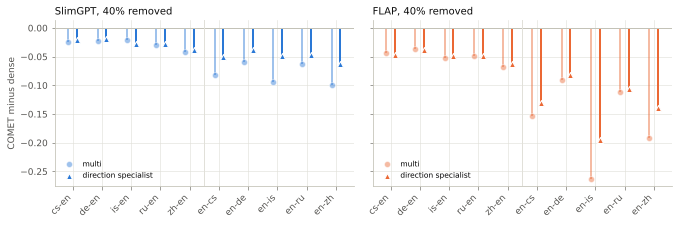

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
x = np.arange(len(DIRECTIONS))
for ax, m in zip(axes, METHODS, strict=True):
    for offset, scope in ((-0.15, "multi"), (0.15, "dir")):
        comp = composite(m, "gen", 40, scope)
        vals = [
            FULLR.score(comp[d], d, "comet") - FULLR.score("alma-7b", d, "comet")
            for d in DIRECTIONS
        ]
        _, marker = SCOPE_STYLE[scope]
        ax.vlines(x + offset, 0, vals, color=COLOR[m], lw=2, alpha=1.0 if scope == "dir" else 0.45)
        ax.scatter(
            x + offset,
            vals,
            marker=marker,
            s=36,
            color=COLOR[m],
            alpha=1.0 if scope == "dir" else 0.45,
            edgecolor="white",
            linewidth=1,
            zorder=3,
            label="direction specialist" if scope == "dir" else "multi",
        )
    ax.axhline(0, color=AXIS, lw=1)
    ax.axvline(4.5, color=GRID, lw=1)
    ax.set_xticks(x, DIRECTIONS, rotation=45, ha="right")
    ax.set_title(f"{METHOD_LABEL[m]}, 40% removed", loc="left")
    ax.legend(fontsize=7.5, loc="lower left")
axes[0].set_ylabel("COMET minus dense")
fig.tight_layout()
save(fig, "per_direction_40")
plt.show()

Into English on the left of each panel, out of English on the right. Generating Icelandic
(low resource) and Chinese (distant script) suffers most, and those are where the direction
specialist recovers most.

## 7. What a specialist specialises in: transfer

Each direction specialist evaluated on all ten directions, minus the multi model of the
same configuration. Full test sets: the ten SlimGPT gen 40% direction models. Pilot: all
120 direction and 60 pair models.

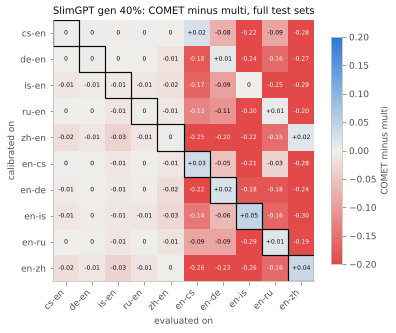

In [23]:
transfer_full = pd.read_csv(FULL / "transfer" / "slimgpt40-gen.csv")
mat = (
    transfer_full[transfer_full.scope == "dir"]
    .pivot_table(index="calibrated_on", columns="direction", values="comet_minus_multi")
    .loc[list(DIRECTIONS), list(DIRECTIONS)]
)


def transfer_heatmap(
    ax, matrix: pd.DataFrame, title: str, vmax: float = 0.2
) -> mpl.image.AxesImage:
    im = ax.imshow(matrix.values, cmap=DIVERGING, vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(matrix.shape[1]), matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(matrix.shape[0]), matrix.index)
    ax.set_xlabel("evaluated on")
    ax.set_ylabel("calibrated on")
    ax.grid(False)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix.values[i, j]
            if np.isnan(v):
                continue
            ax.text(
                j,
                i,
                f"{v:+.2f}" if abs(v) >= 0.005 else "0",
                ha="center",
                va="center",
                fontsize=6,
                color="white" if abs(v) > 0.12 else INK,
            )
            if matrix.index[i] == matrix.columns[j]:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, ec=INK, lw=1.2))
    ax.set_title(title, loc="left")
    return im


fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = transfer_heatmap(ax, mat, "SlimGPT gen 40%: COMET minus multi, full test sets")
fig.colorbar(im, ax=ax, shrink=0.8, label="COMET minus multi")
fig.tight_layout()
save(fig, "transfer_dir_slimgpt40_full")
plt.show()

Mean change against multi by relation between the calibration direction and the evaluated
direction. "Same source" means the same source language, i.e. an en-X specialist writing a
different language Y; "other" covers the remaining off-pair cells.

In [24]:
CATEGORY_LABEL = {
    "own": "own direction",
    "reverse": "its reverse (same pair)",
    "same_target": "other directions into the same target",
    "same_source": "same source, different target language",
    "other": "all other directions",
}


def transfer_summary(res: dict) -> pd.DataFrame:
    rows = []
    for config, entry in res["transfer"].items():
        for scope in ("dir", "pair"):
            summary = entry.get(f"{scope}_summary") or {}
            for cat, v in summary.items():
                if v.get("minus_multi") is not None:
                    rows.append(
                        {
                            "config": config,
                            "scope": scope,
                            "category": cat,
                            "minus_multi": v["minus_multi"],
                            "cells": v["n_cells"],
                        }
                    )
    return pd.DataFrame(rows)


ts_full = transfer_summary(res_full)
ts_pilot = transfer_summary(res_pilot)
cmp = (
    ts_full[ts_full.config == "slimgpt40-gen"]
    .merge(
        ts_pilot[ts_pilot.config == "slimgpt40-gen"],
        on=["config", "scope", "category"],
        suffixes=(" full", " pilot"),
    )
    .set_index("category")
    .loc[list(CATEGORY_LABEL), ["minus_multi full", "minus_multi pilot", "cells full"]]
    .rename(index=CATEGORY_LABEL)
    .round(4)
)
display(
    export(
        cmp,
        "transfer_categories_slimgpt40",
        "Direction specialists, SlimGPT gen 40%: COMET minus multi by category",
    )
)

pilot_cats = ts_pilot.pivot_table(
    index=["config", "scope"], columns="category", values="minus_multi"
)
pilot_cats = pilot_cats[[c for c in CATEGORY_LABEL if c in pilot_cats.columns]].round(4)
display(
    export(
        pilot_cats,
        "transfer_categories_pilot",
        "Pilot: COMET minus multi by transfer category, every configuration",
    )
)

,minus_multi full,minus_multi pilot,cells full
category,,,
own direction,0.0160,0.0175,10
its reverse (same pair),0.0053,0.0060,10
other directions into the same target,-0.0077,-0.0057,20
"same source, different target language",-0.1823,-0.1784,20
all other directions,-0.1029,-0.1027,40


category                own  reverse  same_target  same_source   other
config        scope                                                   
flap20-gen    dir    0.0097   0.0077      -0.0006      -0.0211 -0.0157
              pair   0.0083      NaN          NaN          NaN -0.0120
flap20-ref    dir    0.0078   0.0066      -0.0008      -0.0225 -0.0164
              pair   0.0076      NaN          NaN          NaN -0.0132
flap30-gen    dir    0.0176   0.0180      -0.0020      -0.0744 -0.0370
              pair   0.0172      NaN          NaN          NaN -0.0381
flap30-ref    dir    0.0194   0.0186      -0.0013      -0.0745 -0.0363
              pair   0.0180      NaN          NaN          NaN -0.0366
flap40-gen    dir    0.0165   0.0164      -0.0067      -0.1390 -0.0663
              pair   0.0151      NaN          NaN          NaN -0.0680
flap40-ref    dir    0.0159   0.0179      -0.0062      -0.1330 -0.0662
              pair   0.0159      NaN          NaN          NaN -0.0670
slimgpt20-gen dir    0.0012   0.0008      -0.0037      -0.0591 -0.0381
              pair   0.0017      NaN          NaN          NaN -0.0309
slimgpt20-ref dir   -0.0003  -0.0010      -0.0044      -0.0618 -0.0378
              pair  -0.0005      NaN          NaN          NaN -0.0319
slimgpt30-gen dir    0.0038   0.0002      -0.0058      -0.1179 -0.0697
              pair   0.0047      NaN          NaN          NaN -0.0615
slimgpt30-ref dir    0.0063   0.0013      -0.0049      -0.1154 -0.0673
              pair   0.0052      NaN          NaN          NaN -0.0611
slimgpt40-gen dir    0.0175   0.0060      -0.0057      -0.1784 -0.1027
              pair   0.0187      NaN          NaN          NaN -0.0927
slimgpt40-ref dir    0.0162   0.0088      -0.0070      -0.1815 -0.1030
              pair   0.0169      NaN          NaN          NaN -0.0920

Pilot transfer matrices for every configuration (direction models, 10 x 10, and pair
models, 5 x 10) are in `results/grid-2026-10-06/transfer/*.csv`. The 40 percent ones for
both methods:

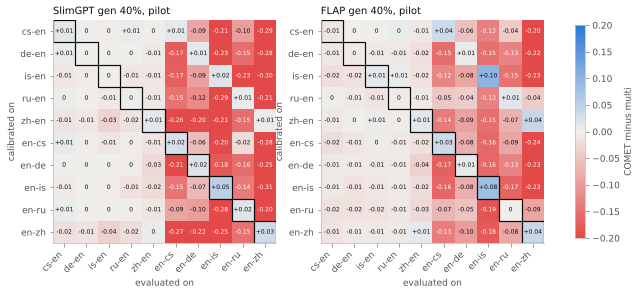

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, m in zip(axes, METHODS, strict=True):
    t = pd.read_csv(PILOT / "transfer" / f"{m}40-gen.csv")
    mt = t[t.scope == "dir"].pivot_table(
        index="calibrated_on", columns="direction", values="comet_minus_multi"
    )
    im = transfer_heatmap(
        ax, mt.loc[list(DIRECTIONS), list(DIRECTIONS)], f"{METHOD_LABEL[m]} gen 40%, pilot"
    )
fig.colorbar(im, ax=axes, shrink=0.8, label="COMET minus multi")
save(fig, "transfer_dir_40_pilot")
plt.show()

## 8. Structure of the subnetworks

### Where each method removes units

Share of heads and FFN channels kept per layer, multi models, generated calibration.

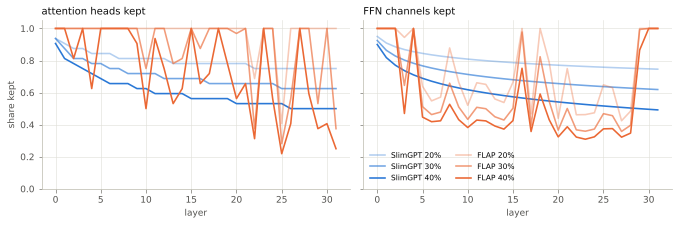

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
for ax, (_part, kept, total, title) in zip(
    axes,
    (
        ("heads", "heads_kept", "heads_total", "attention heads kept"),
        ("ffn", "ffn_kept", "ffn_total", "FFN channels kept"),
    ),
    strict=True,
):
    for m in METHODS:
        for s, alpha in ((20, 0.35), (30, 0.65), (40, 1.0)):
            layers = pd.read_csv(FULL / "structure" / f"alma-7b-{m}{s}-gen-multi.layers.csv")
            ax.plot(
                layers.layer,
                layers[kept] / layers[total],
                color=COLOR[m],
                alpha=alpha,
                lw=1.6,
                label=f"{METHOD_LABEL[m]} {s}%",
            )
    ax.set_title(title, loc="left")
    ax.set_xlabel("layer")
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("share kept")
axes[1].legend(ncol=2, fontsize=7.5, loc="lower left")
fig.tight_layout()
save(fig, "structure_per_layer")
plt.show()

SlimGPT's log-increase schedule prunes the first layer least (a quarter of the target rate)
and each deeper layer a little more, with the same share of heads and FFN channels. FLAP's
AL-AM is uneven: it leaves the FFN of the first three and last three layers almost whole,
takes most of its budget from FFN channels in the middle layers, and removes heads only in
a few scattered layers (2.8 percent of heads at 20 percent, 27.5 at 40).

### Overlap between subnetworks

Jaccard similarity of the kept units of two subnetworks, from the keep masks in
`subnetworks.npz`. The chance level is the expected Jaccard of two random subnetworks with
the same number of kept units in every layer.

240 subnetworks (192 grid models and 48 seed-5678 replicates)


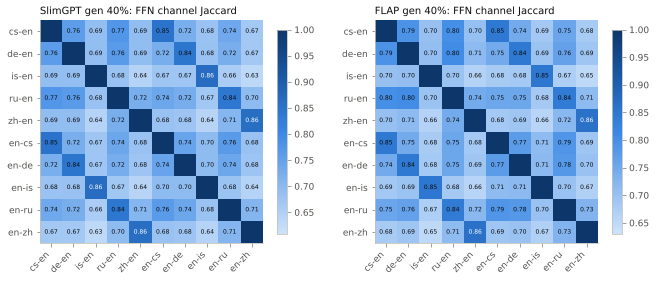

In [27]:
with np.load(PILOT / "subnetworks.npz") as archive:
    masks = {key: archive[key] for key in archive.files}
print(len(masks) // 2, "subnetworks (192 grid models and 48 seed-5678 replicates)")


def jaccard(a: str, b: str, part: str) -> tuple[float, float]:
    """Jaccard of kept units and its chance level given the per-layer kept counts."""
    ma, mb = masks[f"{a}/{part}"], masks[f"{b}/{part}"]
    inter = np.logical_and(ma, mb).sum()
    union = np.logical_or(ma, mb).sum()
    n = ma.shape[1]
    ka, kb = ma.sum(axis=1), mb.sum(axis=1)
    e_inter = (ka * kb / n).sum()
    chance = e_inter / (ka.sum() + kb.sum() - e_inter)
    return inter / union, chance


def jaccard_matrix(names: list[str], labels: list[str], part: str) -> pd.DataFrame:
    out = pd.DataFrame(index=labels, columns=labels, dtype=float)
    for i, a in enumerate(names):
        for j, b in enumerate(names):
            out.iloc[i, j] = jaccard(a, b, part)[0]
    return out


fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, m in zip(axes, METHODS, strict=True):
    names = [f"alma-7b-{m}40-gen-dir-{d}" for d in DIRECTIONS]
    jm = jaccard_matrix(names, list(DIRECTIONS), "ffn")
    off = jm.values[~np.eye(10, dtype=bool)]
    im = ax.imshow(jm.values, cmap=SEQUENTIAL, vmin=off.min() - 0.02, vmax=1)
    ax.set_xticks(range(10), DIRECTIONS, rotation=45, ha="right")
    ax.set_yticks(range(10), DIRECTIONS)
    ax.grid(False)
    for i in range(10):
        for j in range(10):
            if i != j:
                v = jm.values[i, j]
                ax.text(
                    j,
                    i,
                    f"{v:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color="white" if v > 0.85 else INK,
                )
    ax.set_title(f"{METHOD_LABEL[m]} gen 40%: FFN channel Jaccard", loc="left")
    fig.colorbar(im, ax=ax, shrink=0.8)
save(fig, "overlap_dir_40")
plt.show()

Same-language pairs (the two direction subnetworks of one language) against every other
pair, all configurations:

In [28]:
rows = []
for m in METHODS:
    for c in CALIBS:
        for s in SPARSITIES:
            for part in ("ffn", "heads"):
                same, other, chance = [], [], []
                for i, a in enumerate(DIRECTIONS):
                    for b in DIRECTIONS[i + 1 :]:
                        j, ch = jaccard(
                            f"alma-7b-{m}{s}-{c}-dir-{a}", f"alma-7b-{m}{s}-{c}-dir-{b}", part
                        )
                        (same if non_english(a) == non_english(b) else other).append(j)
                        chance.append(ch)
                rows.append(
                    {
                        "method": m,
                        "calib": c,
                        "sparsity": s,
                        "units": part,
                        "same language": f"{min(same):.2f}-{max(same):.2f}",
                        "other pairs": f"{min(other):.2f}-{max(other):.2f}",
                        "chance": round(float(np.mean(chance)), 2),
                    }
                )
overlap_summary = pd.DataFrame(rows).set_index(["method", "calib", "sparsity", "units"])
display(
    export(
        overlap_summary,
        "overlap_summary",
        "Jaccard of direction subnetworks: same language against other pairs",
    )
)

same language other pairs  chance
method  calib sparsity units                                  
slimgpt ref   20       ffn       0.90-0.92   0.78-0.87    0.67
                       heads     0.92-0.94   0.85-0.94    0.67
              30       ffn       0.87-0.89   0.70-0.82    0.55
                       heads     0.90-0.92   0.82-0.94    0.55
              40       ffn       0.84-0.87   0.63-0.78    0.45
                       heads     0.87-0.90   0.76-0.90    0.45
        gen   20       ffn       0.90-0.92   0.78-0.87    0.67
                       heads     0.93-0.95   0.86-0.95    0.67
              30       ffn       0.87-0.89   0.69-0.81    0.55
                       heads     0.90-0.92   0.80-0.94    0.55
              40       ffn       0.84-0.86   0.63-0.77    0.45
                       heads     0.88-0.91   0.77-0.90    0.45
flap    ref   20       ffn       0.85-0.87   0.74-0.86    0.63
                       heads     0.95-0.99   0.91-0.99    0.94
              30       ffn       0.85-0.87   0.70-0.83    0.54
                       heads     0.90-0.95   0.82-0.95    0.82
              40       ffn       0.84-0.86   0.65-0.81    0.47
                       heads     0.86-0.93   0.78-0.93    0.65
        gen   20       ffn       0.85-0.87   0.73-0.86    0.63
                       heads     0.95-0.99   0.91-0.99    0.94
              30       ffn       0.85-0.87   0.70-0.83    0.54
                       heads     0.90-0.94   0.82-0.94    0.81
              40       ffn       0.84-0.86   0.65-0.80    0.47
                       heads     0.86-0.94   0.77-0.93    0.65

Closest pair of languages, and the seed stability of the selection (seed 1234 against
5678, SlimGPT ref):

In [29]:
pairs_ffn = {
    (a, b): jaccard(f"alma-7b-slimgpt40-gen-dir-{a}", f"alma-7b-slimgpt40-gen-dir-{b}", "ffn")[0]
    for i, a in enumerate(DIRECTIONS)
    for b in DIRECTIONS[i + 1 :]
    if non_english(a) != non_english(b)
}
top = sorted(pairs_ffn.items(), key=lambda kv: -kv[1])[:4]
print(
    "most similar cross-language direction pairs, SlimGPT gen 40%, FFN:",
    [(f"{a} / {b}", round(v, 3)) for (a, b), v in top],
)

rows = []
for s in SPARSITIES:
    for scope_names in (["multi"], [f"pair-{x}" for x in LANGS], [f"dir-{d}" for d in DIRECTIONS]):
        for part in ("ffn", "heads"):
            vals = [
                jaccard(f"alma-7b-slimgpt{s}-ref-{k}", f"alma-7b-s2-slimgpt{s}-ref-{k}", part)[0]
                for k in scope_names
            ]
            rows.append(
                {
                    "sparsity": s,
                    "scope": scope_names[0].split("-")[0],
                    "units": part,
                    "Jaccard seed 1234 vs 5678": f"{min(vals):.3f}-{max(vals):.3f}",
                }
            )
display(
    export(
        pd.DataFrame(rows).set_index(["sparsity", "scope", "units"]),
        "seed_stability_masks",
        "Selection stability across calibration draws",
    )
)

most similar cross-language direction pairs, SlimGPT gen 40%, FFN: [('cs-en / ru-en', np.float64(0.774)), ('de-en / ru-en', np.float64(0.764)), ('en-cs / en-ru', np.float64(0.763)), ('cs-en / de-en', np.float64(0.76))]


Jaccard seed 1234 vs 5678
sparsity scope units                          
20       multi ffn                 0.954-0.954
               heads               0.993-0.993
         pair  ffn                 0.954-0.967
               heads               0.971-0.988
         dir   ffn                 0.953-0.976
               heads               0.976-0.995
30       multi ffn                 0.937-0.937
               heads               0.975-0.975
         pair  ffn                 0.935-0.953
               heads               0.967-0.986
         dir   ffn                 0.934-0.967
               heads               0.970-0.989
40       multi ffn                 0.922-0.922
               heads               0.981-0.981
         pair  ffn                 0.919-0.943
               heads               0.952-0.987
         dir   ffn                 0.917-0.958
               heads               0.956-0.981

## 9. Robustness to the calibration draw

The 48 SlimGPT `ref` models rebuilt on calibration sets drawn with seed 5678 instead of
1234, scored on the pilot suite. For Icelandic the two draws share 63 percent of their
sources, since only 2,009 pairs exist.

In [30]:
s2_head = headline(
    SEED2R, metrics=("comet",), prefix="alma-7b-s2", methods=("slimgpt",), calibs=("ref",)
)
s1_head = head_pilot[(head_pilot.method == "slimgpt") & (head_pilot.calib == "ref")]
seeds = s1_head.merge(
    s2_head, on=["method", "calib", "sparsity", "scope"], suffixes=(" seed 1234", " seed 5678")
)
seeds["difference"] = seeds["comet seed 5678"] - seeds["comet seed 1234"]
seeds = seeds.set_index(["sparsity", "scope"])[
    ["comet seed 1234", "comet seed 5678", "difference"]
].round(4)
display(export(seeds, "seed_replicate", "SlimGPT ref, pilot COMET under two calibration draws"))
print("largest |difference|:", seeds.difference.abs().max())

rows = []
for s in SPARSITIES:
    for scope in ("pair", "dir"):
        r1 = contrast(
            PILOTR, composite("slimgpt", "ref", s, "multi"), composite("slimgpt", "ref", s, scope)
        )
        r2 = contrast(
            SEED2R,
            composite("slimgpt", "ref", s, "multi", prefix="alma-7b-s2"),
            composite("slimgpt", "ref", s, scope, prefix="alma-7b-s2"),
        )
        rows.append(
            {
                "sparsity": s,
                "scope": scope,
                "gain seed 1234": round(r1["delta"], 4),
                "p seed 1234": fmt_p(r1["p"]),
                "gain seed 5678": round(r2["delta"], 4),
                "p seed 5678": fmt_p(r2["p"]),
            }
        )
display(
    export(
        pd.DataFrame(rows).set_index(["sparsity", "scope"]),
        "seed_replicate_specialist_gain",
        "Specialist gain under both calibration draws, pilot",
    )
)

comet seed 1234  comet seed 5678  difference
sparsity scope                                              
20       multi           0.8374           0.8360     -0.0013
         pair            0.8369           0.8380      0.0011
         dir             0.8371           0.8363     -0.0008
30       multi           0.8219           0.8223      0.0005
         pair            0.8271           0.8268     -0.0003
         dir             0.8282           0.8282      0.0000
40       multi           0.7914           0.7954      0.0040
         pair            0.8083           0.8067     -0.0016
         dir             0.8076           0.8094      0.0018

largest |difference|: 0.004


gain seed 1234 p seed 1234  gain seed 5678 p seed 5678
sparsity scope                                                        
20       pair          -0.0005       0.640          0.0020       0.065
         dir           -0.0003       0.796          0.0003       0.787
30       pair           0.0052      <0.001          0.0044      <0.001
         dir            0.0063      <0.001          0.0059      <0.001
40       pair           0.0169      <0.001          0.0113      <0.001
         dir            0.0162      <0.001          0.0140      <0.001

## 10. LoRA repair

### Multi models

Repaired minus pruned on all ten directions, full test sets. Recovered is the share of the
gap to dense that repair closes: (repaired - pruned) / (dense - pruned), with the sign
flipped for MetricX.

In [31]:
def recovered(dense, pruned, repaired):
    return (repaired - pruned) / (dense - pruned)


rows = []
for entry in res_full["repair"]:
    system, source = entry["system"], entry["source"]
    if "-multi-" not in system:
        continue
    comp_s, comp_r = dict.fromkeys(DIRECTIONS, source), dict.fromkeys(DIRECTIONS, system)
    rc = contrast(FULLR, comp_s, comp_r, "comet")
    rx = contrast(FULLR, comp_s, comp_r, "metricx")
    rows.append(
        {
            "repaired model": source.replace("alma-7b-", ""),
            "COMET pruned": round(rc["base"], 4),
            "COMET repaired": round(rc["system"], 4),
            "COMET 95% CI": fmt_ci(rc["ci_lo"], rc["ci_hi"]),
            "COMET recovered %": round(
                100 * recovered(dense_full["comet"], rc["base"], rc["system"])
            ),
            "MetricX pruned": round(rx["base"], 3),
            "MetricX repaired": round(rx["system"], 3),
            "MetricX recovered %": round(
                100 * recovered(dense_full["metricx"], rx["base"], rx["system"])
            ),
            "BLEU pruned": round(FULLR.macro(comp_s, "bleu"), 2),
            "BLEU repaired": round(FULLR.macro(comp_r, "bleu"), 2),
            "p (COMET / MetricX)": f"{fmt_p(rc['p'])} / {fmt_p(rx['p'])}",
        }
    )
repair_multi = pd.DataFrame(rows).set_index("repaired model").sort_index()
display(export(repair_multi, "repair_multi_full", "LoRA repair of multi models, full test sets"))

,COMET pruned,COMET repaired,COMET 95% CI,COMET recovered %,MetricX pruned,MetricX repaired,MetricX recovered %,BLEU pruned,BLEU repaired,p (COMET / MetricX)
repaired model,,,,,,,,,,
flap30-gen-multi,0.7823,0.8239,"[+0.0400, +0.0432]",64,5.231,3.831,61,23.55,27.05,<0.001 / <0.001
flap40-gen-multi,0.7417,0.8113,"[+0.0677, +0.0714]",66,6.665,4.252,65,20.17,25.91,<0.001 / <0.001
flap40-ref-multi,0.7414,0.8111,"[+0.0679, +0.0717]",66,6.697,4.216,66,20.31,25.72,<0.001 / <0.001
slimgpt20-ref-multi,0.8361,0.8391,"[+0.0020, +0.0039]",26,3.356,3.234,29,27.76,28.51,<0.001 / <0.001
slimgpt30-gen-multi,0.8227,0.8312,"[+0.0074, +0.0095]",34,3.815,3.474,39,25.94,27.48,<0.001 / <0.001
slimgpt40-gen-multi,0.7937,0.8196,"[+0.0245, +0.0273]",48,4.866,3.915,49,23.27,26.16,<0.001 / <0.001
slimgpt40-ref-multi,0.7931,0.8195,"[+0.0250, +0.0278]",48,4.857,3.916,49,23.24,26.10,<0.001 / <0.001


### Pair models, each repaired on its own pair

Scored on the model's own two directions.

In [32]:
rows = []
for entry in res_full["repair"]:
    system, source = entry["system"], entry["source"]
    if "-pair-" not in system:
        continue
    lang = source.rsplit("-", 1)[1]
    own = (f"{lang}-en", f"en-{lang}")
    comp_s, comp_r = dict.fromkeys(own, source), dict.fromkeys(own, system)
    rc = contrast(FULLR, comp_s, comp_r, "comet")
    rx = contrast(FULLR, comp_s, comp_r, "metricx")
    dense_own = FULLR.macro(dict.fromkeys(own, "alma-7b"), "comet")
    dense_own_mx = FULLR.macro(dict.fromkeys(own, "alma-7b"), "metricx")
    rows.append(
        {
            "source": source.replace("alma-7b-", "").rsplit("-pair-", 1)[0],
            "pair": lang,
            "steps": steps[f"pair {lang}"],
            "COMET dense": round(dense_own, 4),
            "COMET pruned": round(rc["base"], 4),
            "COMET repaired": round(rc["system"], 4),
            "COMET recovered %": round(100 * recovered(dense_own, rc["base"], rc["system"])),
            "COMET p": fmt_p(rc["p"]),
            "MetricX recovered %": round(100 * recovered(dense_own_mx, rx["base"], rx["system"])),
            "MetricX p": fmt_p(rx["p"]),
            "BLEU pruned": round(FULLR.macro(comp_s, "bleu"), 2),
            "BLEU repaired": round(FULLR.macro(comp_r, "bleu"), 2),
        }
    )
repair_pair = pd.DataFrame(rows).set_index(["source", "pair"]).sort_index()
display(
    export(
        repair_pair,
        "repair_pair_full",
        "LoRA repair of pair models on their own pair, full test sets",
    )
)

steps  COMET dense  COMET pruned  COMET repaired  COMET recovered % COMET p  MetricX recovered % MetricX p  BLEU pruned  BLEU repaired
source        pair                                                                                                                                        
flap30-gen    cs      185       0.8675        0.8269          0.8462                 47  <0.001                   51    <0.001        27.81          31.01
              de      219       0.8431        0.8139          0.8293                 53  <0.001                   54    <0.001        25.27          27.27
              is       28       0.8508        0.7908          0.8216                 51  <0.001                   45    <0.001        22.75          23.80
              ru      231       0.8538        0.8079          0.8312                 51  <0.001                   51    <0.001        25.16          27.83
              zh      237       0.8222        0.7660          0.8021                 64  <0.001                   65    <0.001        21.30          26.20
flap40-gen    cs      185       0.8675        0.7797          0.8312                 59  <0.001                   59    <0.001        23.20          28.68
              de      219       0.8431        0.7825          0.8176                 58  <0.001                   55    <0.001        21.67          25.46
              is       28       0.8508        0.7268          0.8018                 61  <0.001                   57    <0.001        18.10          21.56
              ru      231       0.8538        0.7773          0.8181                 53  <0.001                   52    <0.001        21.60          26.22
              zh      237       0.8222        0.7239          0.7904                 68  <0.001                   69    <0.001        17.13          24.97
slimgpt30-gen cs      185       0.8675        0.8500          0.8566                 37  <0.001                   42    <0.001        29.44          31.70
              de      219       0.8431        0.8298          0.8353                 41  <0.001                   42    <0.001        25.75          27.44
              is       28       0.8508        0.8322          0.8365                 23   0.002                   17     0.016        26.03          25.47
              ru      231       0.8538        0.8336          0.8395                 30  <0.001                   33    <0.001        27.59          28.74
              zh      237       0.8222        0.7980          0.8087                 44  <0.001                   58    <0.001        25.11          26.86
slimgpt40-gen cs      185       0.8675        0.8310          0.8447                 37  <0.001                   41    <0.001        27.45          29.77
              de      219       0.8431        0.8153          0.8287                 48  <0.001                   40    <0.001        24.21          26.24
              is       28       0.8508        0.8108          0.8252                 36  <0.001                   29    <0.001        22.65          23.53
              ru      231       0.8538        0.8153          0.8306                 40  <0.001                   37    <0.001        25.42          27.13
              zh      237       0.8222        0.7718          0.7948                 46  <0.001                   48    <0.001        21.92          25.01

### Does specialisation still pay after repair?

Five pair models each repaired on its own pair, against the multi model repaired on all ten
directions. Generated calibration. The multi repair sees about five times the training
data of each pair repair.

In [33]:
rows = []
for m in METHODS:
    for s in (30, 40):
        multi_l = composite(m, "gen", s, "multi", lora=True)
        pair_l = composite(m, "gen", s, "pair", lora=True)
        before = contrast(FULLR, composite(m, "gen", s, "multi"), composite(m, "gen", s, "pair"))
        rc = contrast(FULLR, multi_l, pair_l)
        rx = contrast(FULLR, multi_l, pair_l, "metricx")
        rows.append(
            {
                "method": METHOD_LABEL[m],
                "removed": f"{s}%",
                "multi + LoRA": round(rc["base"], 4),
                "pair + LoRA": round(rc["system"], 4),
                "pair - multi after repair": round(rc["delta"], 4),
                "95% CI": fmt_ci(rc["ci_lo"], rc["ci_hi"]),
                "p": fmt_p(rc["p"]),
                "MetricX pair - multi": round(rx["delta"], 3),
                "MetricX p": fmt_p(rx["p"]),
                "pair - multi before repair": round(before["delta"], 4),
            }
        )
after_repair = pd.DataFrame(rows).set_index(["method", "removed"])
display(
    export(
        after_repair, "specialisation_after_repair", "Pair minus multi composites after LoRA repair"
    )
)

multi + LoRA  pair + LoRA  pair - multi after repair              95% CI       p  MetricX pair - multi MetricX p  pair - multi before repair
method  removed                                                                                                                                              
SlimGPT 30%            0.8312       0.8353                     0.0041  [+0.0031, +0.0051]  <0.001                -0.103    <0.001                      0.0060
        40%            0.8196       0.8248                     0.0052  [+0.0041, +0.0064]  <0.001                -0.132    <0.001                      0.0152
FLAP    30%            0.8239       0.8261                     0.0022  [+0.0010, +0.0034]  <0.001                -0.073     0.003                      0.0188
        40%            0.8113       0.8118                     0.0006  [-0.0008, +0.0020]   0.409                 0.037     0.167                      0.0163

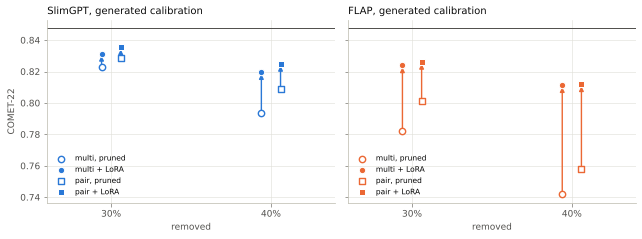

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, m in zip(axes, METHODS, strict=True):
    ax.axhline(dense_full["comet"], color=COLOR["dense"], lw=1)
    for scope, dx in (("multi", -0.6), ("pair", 0.6)):
        ls, marker = SCOPE_STYLE[scope]
        xs, before, after = [], [], []
        for s in SPARSITIES:
            comp_l = composite(m, "gen", s, scope, lora=True)
            if not all(v in FULLR.runs for v in comp_l.values()):
                continue
            xs.append(s + dx)
            before.append(FULLR.macro(composite(m, "gen", s, scope), "comet"))
            after.append(FULLR.macro(comp_l, "comet"))
        for x0, b, a in zip(xs, before, after, strict=True):
            ax.annotate(
                "", (x0, a), (x0, b), arrowprops={"arrowstyle": "-|>", "color": COLOR[m], "lw": 1.4}
            )
        ax.scatter(
            xs,
            before,
            marker=marker,
            s=40,
            facecolor="white",
            edgecolor=COLOR[m],
            lw=1.4,
            zorder=3,
            label=f"{scope}, pruned",
        )
        ax.scatter(
            xs,
            after,
            marker=marker,
            s=40,
            color=COLOR[m],
            edgecolor="white",
            lw=1,
            zorder=3,
            label=f"{scope} + LoRA",
        )
    ax.set_xticks((30, 40), ["30%", "40%"])
    ax.set_xlim(26, 44)
    ax.set_title(f"{METHOD_LABEL[m]}, generated calibration", loc="left")
    ax.set_xlabel("removed")
    ax.legend(fontsize=7.5, loc="lower left")
axes[0].set_ylabel("COMET-22")
fig.tight_layout()
save(fig, "repair")
plt.show()

The SlimGPT 20 percent multi repair is the reference-calibration model, the only 20 percent
repair that was run, and is listed in the multi table above. Pair models with own-pair
repair at 20 percent were not run.

## 11. Output behaviour

Rates over all segments, macro over directions, multi models on the full test sets.
Budget hit: the output reached the 256-token generation limit. Off-target: language
identification says the output is not in the target language.

In [35]:
behaviour_cols = [
    "budget_hit_rate",
    "repetition_rate",
    "off_target_rate",
    "source_copy_rate",
    "empty_rate",
    "length_ratio",
]
rows = []
for m in METHODS:
    for c in CALIBS:
        for s in SPARSITIES:
            sys_ = f"alma-7b-{m}{s}-{c}-multi"
            sub = long_full[long_full.system == sys_]
            rows.append(
                {
                    "system": f"{METHOD_LABEL[m]} {c} {s}%",
                    **sub[behaviour_cols].mean().to_dict(),
                    "max budget hit (one direction)": sub.budget_hit_rate.max(),
                }
            )
sub = long_full[long_full.system == "alma-7b"]
rows.append(
    {
        "system": "dense",
        **sub[behaviour_cols].mean().to_dict(),
        "max budget hit (one direction)": sub.budget_hit_rate.max(),
    }
)
behaviour = pd.DataFrame(rows).set_index("system")
behaviour[[c for c in behaviour.columns if c != "length_ratio"]] *= 100
behaviour = behaviour.round(2).rename(columns=lambda c: c.replace("_rate", " %").replace("_", " "))
display(export(behaviour, "behaviour_multi_full", "Output behaviour, multi models, full test sets"))

,budget hit %,repetition %,off target %,source copy %,empty %,length ratio,max budget hit (one direction)
system,,,,,,,
SlimGPT ref 20%,0.07,0.02,0.27,0.19,0.0,0.96,0.27
SlimGPT ref 30%,0.05,0.02,0.21,0.12,0.0,0.95,0.10
SlimGPT ref 40%,0.21,0.08,0.37,0.21,0.0,0.95,0.64
SlimGPT gen 20%,0.06,0.03,0.29,0.18,0.0,0.96,0.14
SlimGPT gen 30%,0.08,0.02,0.26,0.16,0.0,0.96,0.29
SlimGPT gen 40%,0.22,0.09,0.34,0.19,0.0,0.95,0.69
FLAP ref 20%,0.09,0.02,0.27,0.11,0.0,0.95,0.49
FLAP ref 30%,0.85,0.31,0.36,0.20,0.0,0.97,3.60
FLAP ref 40%,1.31,0.45,0.26,0.13,0.0,0.96,4.80


## 12. The pilot as a proxy for the full test sets

The 36 headline composites (method x calibration x sparsity x scope) and the 27 repairs on
their own directions, pilot (first 300 segments per direction) against the full test sets.

headline composites: Pearson r = 0.9995, Spearman rho = 0.9923, mean |full - pilot| = 0.0013, max 0.0044
BLEU: Pearson r = 0.9980
specialist contrasts significant at 0.05: pilot 20 of 24, full 24 of 24


pilot delta  pilot p  full delta  full p
config          scope                                          
slimgpt ref 20% pair       -0.0005   0.6404      0.0022   0.001
                dir        -0.0003   0.7962      0.0021   0.001
slimgpt gen 20% pair        0.0017   0.1049      0.0028   0.001
                dir         0.0012   0.2418      0.0023   0.001

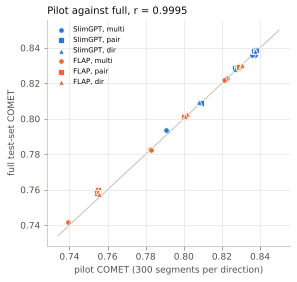

In [36]:
both = head_pilot.merge(
    head_full, on=["method", "calib", "sparsity", "scope"], suffixes=("_pilot", "_full")
)
r = np.corrcoef(both.comet_pilot, both.comet_full)[0, 1]
rho = both[["comet_pilot", "comet_full"]].rank().corr().iloc[0, 1]
gap = (both.comet_full - both.comet_pilot).abs()
print(
    f"headline composites: Pearson r = {r:.4f}, Spearman rho = {rho:.4f}, "
    f"mean |full - pilot| = {gap.mean():.4f}, max {gap.max():.4f}"
)
print(f"BLEU: Pearson r = {np.corrcoef(both.bleu_pilot, both.bleu_full)[0, 1]:.4f}")

full_by_key = {(h["method"], h["calib"], h["sparsity"]): h for h in res_full["headline"]}
rows = []
for h_p in res_pilot["headline"]:
    h_f = full_by_key[(h_p["method"], h_p["calib"], h_p["sparsity"])]
    for scope in ("pair", "dir"):
        rows.append(
            {
                "config": f"{h_p['method']} {h_p['calib']} {h_p['sparsity']}%",
                "scope": scope,
                "pilot delta": h_p[f"{scope}_minus_multi_comet"]["delta"],
                "pilot p": h_p[f"{scope}_minus_multi_comet"]["p_value"],
                "full delta": h_f[f"{scope}_minus_multi_comet"]["delta"],
                "full p": h_f[f"{scope}_minus_multi_comet"]["p_value"],
            }
        )
sig = pd.DataFrame(rows)
print(
    "specialist contrasts significant at 0.05: pilot",
    int((sig["pilot p"] < 0.05).sum()),
    "of 24, full",
    int((sig["full p"] < 0.05).sum()),
    "of 24",
)
display(sig[sig["pilot p"] >= 0.05].set_index(["config", "scope"]).round(4))

fig, ax = plt.subplots(figsize=(4.2, 4))
for m in METHODS:
    for scope in SCOPES:
        sub = both[(both.method == m) & (both.scope == scope)]
        _, marker = SCOPE_STYLE[scope]
        ax.scatter(
            sub.comet_pilot,
            sub.comet_full,
            marker=marker,
            color=COLOR[m],
            s=30,
            edgecolor="white",
            lw=0.8,
            label=f"{METHOD_LABEL[m]}, {scope}",
        )
lo, hi = both[["comet_pilot", "comet_full"]].min().min() - 0.005, 0.85
ax.plot([lo, hi], [lo, hi], color=AXIS, lw=1, zorder=0)
ax.set_xlabel("pilot COMET (300 segments per direction)")
ax.set_ylabel("full test-set COMET")
ax.set_title(f"Pilot against full, r = {r:.4f}", loc="left")
ax.legend(fontsize=7, loc="upper left")
fig.tight_layout()
save(fig, "pilot_vs_full")
plt.show()

## 13. Ablations and earlier experiments

### FLAP needs its own structure search (pilot)

FLAP with AL-AM against a simpler budget that ranks heads and FFN channels separately
across layers (`global`), multi scope. Pilot suite.

In [37]:
rows = []
for c in CALIBS:
    for s in SPARSITIES:
        alam = f"alma-7b-flap{s}-{c}-multi"
        glob = f"{alam}-global"
        rows.append(
            {
                "calib": c,
                "sparsity": s,
                "AL-AM COMET": PILOTR.macro(dict.fromkeys(DIRECTIONS, alam), "comet"),
                "global COMET": PILOTR.macro(dict.fromkeys(DIRECTIONS, glob), "comet"),
            }
        )
flap_budget = pd.DataFrame(rows).set_index(["calib", "sparsity"]).round(4)
display(
    export(
        flap_budget, "flap_budget_ablation", "FLAP: AL-AM against a separate global budget, pilot"
    )
)
print(
    "the global budget collapses beyond 20 percent: 55 percent of outputs loop to the "
    "token budget at 30 (overnight log)"
)

AL-AM COMET  global COMET
calib sparsity                           
ref   20             0.8221        0.8321
      30             0.7823        0.4281
      40             0.7393        0.5683
gen   20             0.8209        0.8312
      30             0.7830        0.4250
      40             0.7392        0.5897

the global budget collapses beyond 20 percent: 55 percent of outputs loop to the token budget at 30 (overnight log)


### The SlimGPT fix (pilot)

Before the grid ran, SlimGPT's column-order sweep (inherited from SparseGPT) was replaced by
the exact joint least-squares refit with greedy re-scoring. Same setting, 20 percent, multi,
reference calibration, log-increase:

In [38]:
old = dict.fromkeys(DIRECTIONS, "alma-7b-slimgpt20-ref-multi-oldcode")
new = dict.fromkeys(DIRECTIONS, "alma-7b-slimgpt20-ref-multi")
fix = contrast(PILOTR, old, new)
print(
    f"old code {fix['base']:.4f} COMET, fixed {fix['system']:.4f}; "
    f"delta {fix['delta']:+.4f} {fmt_ci(fix['ci_lo'], fix['ci_hi'])}, p {fmt_p(fix['p'])}"
)
print("BLEU:", round(PILOTR.macro(old, "bleu"), 2), "->", round(PILOTR.macro(new, "bleu"), 2))

old code 0.8354 COMET, fixed 0.8374; delta +0.0020 [+0.0000, +0.0040], p 0.054
BLEU: 27.31 -> 27.72


On the pilot suite the gain is small and not significant at 0.05. The fix was made for
correctness: in the old sweep a removed column was compensated only by the columns after
it, so the last heads of each layer got no compensation and looked more important than
early ones. An independent reimplementation agrees with the new code to within 2e-5 on the
weights, with identical selections.

### The 29 September pilot (old SlimGPT code, no repair)

Layer schedules, pair-specific subnetworks with small calibration, FLAP, and 50 percent
pruning. Pair models there had 256 calibration segments against multi's 1,280, which is why
they lost to multi; at equal calibration size (section 4) the result reverses.

In [39]:
display(export(early, "early_pilot_systems", "29 September pilot, all systems"))

,sparsity,calibration,bleu,chrf,comet,length_ratio,truncated_pct
system,,,,,,,
alma-7b,0.0,NaN,30.35,51.14,0.8474,0.964,0.0
alma-7b-slimgpt20-multi,0.2,"1,280 prompts",20.65,41.71,0.8148,0.909,0.1
alma-7b-slimgpt20-multi-uniform,0.2,"1,280 prompts",23.01,43.81,0.8222,0.890,0.0
alma-7b-slimgpt20-multi-log,0.2,"1,280 prompts",21.92,42.92,0.8223,0.902,0.1
alma-7b-slimgpt20-multi-target,0.2,"1,280 prompt+ref",28.33,49.33,0.8367,0.949,0.0
alma-7b-slimgpt20-multi-256,0.2,"2,560 prompts",21.22,42.28,0.8195,0.904,0.2
alma-7b-slimgpt20-cs,0.2,"256 prompts, cs",12.28,31.73,0.6845,0.962,2.1
alma-7b-slimgpt20-de,0.2,"256 prompts, de",10.37,29.08,0.6482,0.999,1.8
alma-7b-slimgpt20-is,0.2,"256 prompts, is",13.05,33.36,0.7105,0.968,1.3


Efficiency (29 September, one A100, Hugging Face eager generation). Pruning reduces memory
and parameters; it gives no speedup in this setup, because generation is bound by per-step
overhead rather than by matrix sizes. Throughput was not measured in the final grid.

In [40]:
bench = pd.read_csv(EARLY / "bench.csv").set_index("system")
bench["memory reduction x"] = (bench.loc["alma-7b", "resident_gib"] / bench.resident_gib).round(2)
display(export(bench, "efficiency_bench", "Efficiency benchmark, 29 September pilot"))

,params_b,resident_gib,peak_vram_b1_gib,tok_s_b1,tok_s_b8,first_token_ms,memory reduction x
system,,,,,,,
alma-7b,6.74,12.55,12.68,38.1,239.6,29.3,1.00
alma-7b-slimgpt20-multi,5.44,10.22,10.34,36.6,227.5,30.7,1.23
alma-7b-slimgpt20-multi-uniform,5.47,10.19,10.30,36.5,225.9,30.8,1.23
alma-7b-slimgpt50-multi,3.50,6.61,6.69,38.0,233.4,30.5,1.90


## 14. Best systems and key numbers

In [41]:
best = [("dense ALMA-7B", DENSE)]
best += [
    (
        "20%: SlimGPT ref, multi + LoRA",
        dict.fromkeys(DIRECTIONS, "alma-7b-slimgpt20-ref-multi-lora"),
    ),
    ("20%: SlimGPT gen, 5 pair models", composite("slimgpt", "gen", 20, "pair")),
    (
        "30%: SlimGPT gen, 5 pair models + own-pair LoRA",
        composite("slimgpt", "gen", 30, "pair", lora=True),
    ),
    (
        "40%: SlimGPT gen, 5 pair models + own-pair LoRA",
        composite("slimgpt", "gen", 40, "pair", lora=True),
    ),
    (
        "40%: SlimGPT gen, multi + LoRA",
        dict.fromkeys(DIRECTIONS, "alma-7b-slimgpt40-gen-multi-lora"),
    ),
    (
        "40%: FLAP gen, 5 pair models + own-pair LoRA",
        composite("flap", "gen", 40, "pair", lora=True),
    ),
]
rows = []
for label, comp in best:
    c_ = FULLR.macro(comp, "comet")
    rows.append(
        {
            "system": label,
            "COMET": round(c_, 4),
            "share of dense COMET %": round(100 * c_ / dense_full["comet"], 1),
            "MetricX": round(FULLR.macro(comp, "metricx"), 3),
            "BLEU": round(FULLR.macro(comp, "bleu"), 2),
            "chrF++": round(FULLR.macro(comp, "chrf"), 2),
        }
    )
best_table = pd.DataFrame(rows).set_index("system")
display(export(best_table, "best_systems", "Best system at each sparsity, full test sets"))
kept_40 = 1 - res_full["structure"]["alma-7b-slimgpt40-gen-pair-de"]["params_removed_frac_all"]
print(f"a 40 percent model keeps {100 * kept_40:.1f} percent of the dense parameter count")

,COMET,share of dense COMET %,MetricX,BLEU,chrF++
system,,,,,
dense ALMA-7B,0.8475,100.0,2.937,30.32,51.13
"20%: SlimGPT ref, multi + LoRA",0.8391,99.0,3.234,28.51,49.55
"20%: SlimGPT gen, 5 pair models",0.8387,99.0,3.258,28.27,49.59
"30%: SlimGPT gen, 5 pair models + own-pair LoRA",0.8353,98.6,3.371,28.04,49.23
"40%: SlimGPT gen, 5 pair models + own-pair LoRA",0.8248,97.3,3.783,26.34,47.78
"40%: SlimGPT gen, multi + LoRA",0.8196,96.7,3.915,26.16,47.27
"40%: FLAP gen, 5 pair models + own-pair LoRA",0.8118,95.8,4.288,25.38,46.69


a 40 percent model keeps 61.6 percent of the dense parameter count


Numbers for the abstract and conclusion, all from the tables above (full test sets unless
stated):

In [42]:
sg = method_full.xs("multi", level="scope").xs("gen", level="calib")["comet delta"]
spec40 = spec_full[(spec_full.sparsity == 40)]["comet delta"]
spec20 = spec_full[(spec_full.method == "slimgpt") & (spec_full.sparsity == 20)]["comet delta"]
BEST40 = "40%: SlimGPT gen, 5 pair models + own-pair LoRA"
writes_other = cmp.loc[CATEGORY_LABEL["same_source"]].iloc[0]
rec = repair_multi["COMET recovered %"]
lines = [
    f"- Dense ALMA-7B: COMET {dense_full['comet']:.4f}, MetricX {dense_full['metricx']:.3f}, "
    f"BLEU {dense_full['bleu']:.2f}.",
    f"- SlimGPT minus FLAP, multi, generated calibration: {sg.loc[20]:+.3f} / "
    f"{sg.loc[30]:+.3f} / {sg.loc[40]:+.3f} COMET at 20 / 30 / 40 percent.",
    f"- Specialists minus multi at 40 percent: {spec40.min():+.3f} to {spec40.max():+.3f} "
    f"COMET; SlimGPT at 20 percent {spec20.min():+.4f} to {spec20.max():+.4f}.",
    f"- Specialist contrasts favouring the specialists: {favour} of {2 * len(spec_full)} "
    "(COMET and MetricX).",
    "- Reference against generated calibration: largest |COMET difference| "
    f"{rg_full['comet delta'].abs().max():.4f}; Holm-significant contrasts: "
    f"{int((rg_full['comet p Holm'] < 0.05).sum() + (rg_full['metricx p Holm'] < 0.05).sum())} "
    "of 36.",
    f"- Transfer, SlimGPT gen 40% direction specialists: own direction {cmp.iloc[0, 0]:+.3f}, "
    f"writing a different language {writes_other:+.3f} COMET against multi.",
    f"- LoRA repair, multi, recovered share of the COMET gap: {rec.min()} to {rec.max()} percent.",
    f"- Pilot against full: Pearson r {r:.4f}, Spearman rho {rho:.3f} over 36 composites.",
    f"- Best 40 percent system: {best_table.loc[BEST40, 'COMET']:.4f} COMET, "
    f"{best_table.loc[BEST40, 'share of dense COMET %']} percent of dense, "
    f"each model {100 * kept_40:.1f} percent of the parameters.",
]
print("\n".join(lines))

- Dense ALMA-7B: COMET 0.8475, MetricX 2.937, BLEU 30.32.
- SlimGPT minus FLAP, multi, generated calibration: +0.014 / +0.040 / +0.052 COMET at 20 / 30 / 40 percent.
- Specialists minus multi at 40 percent: +0.015 to +0.018 COMET; SlimGPT at 20 percent +0.0021 to +0.0028.
- Specialist contrasts favouring the specialists: 48 of 48 (COMET and MetricX).
- Reference against generated calibration: largest |COMET difference| 0.0015; Holm-significant contrasts: 0 of 36.
- Transfer, SlimGPT gen 40% direction specialists: own direction +0.016, writing a different language -0.182 COMET against multi.
- LoRA repair, multi, recovered share of the COMET gap: 26 to 66 percent.
- Pilot against full: Pearson r 0.9995, Spearman rho 0.992 over 36 composites.
- Best 40 percent system: 0.8248 COMET, 97.3 percent of dense, each model 61.6 percent of the parameters.


## 15. Caveats for the limitations section

- **Greedy decoding throughout.** Scores are not comparable with ALMA's published beam-5
  numbers.
- **One calibration seed** for most of the grid. The SlimGPT `ref` replicate (section 9)
  moves composites by up to 0.004 COMET, which is below every effect reported except the 20
  percent SlimGPT specialist gain and the reference against generated differences.
- **Mixed hardware.** Models ran on A100 and H100 nodes; greedy decoding can differ in rare
  tie-breaks across GPUs. No systematic effect.
- **Throughput not measured** in the final grid. Earlier benchmarks show memory savings and
  no speedup under eager Hugging Face generation.
- **The repair comparison favours multi** in data: the multi repair trains on all of ALMA's
  parallel data, about five times what each pair repair sees.
- **FLORES-200 is not a held-out test set for ALMA.** All 1,012 test sentences checked in
  de-en, is-en and zh-en appear in ALMA's fine-tuning data, so it was not used.
- **Repair data collisions**: two training segments whose sources occur in WMT22 were removed
  from the repair set (`results/pilot-2026-09-29/repair_set_collisions.csv`).
- **Earlier results used the old SlimGPT code**: the 29 September pilot and the
  layer-protection and direction-scope experiments on the teammates' branches.
- **Not in git**: hypotheses (710 MB, `runs/` on scur0560) and checkpoints
  (`/scratch-shared/scur0560/checkpoints/`, purged around 20 October 2026). Translation
  examples and error analysis need the hypotheses.

## Exported files

In [43]:
for kind in ("tables", "figures"):
    files = sorted(p.name for p in (OUT / kind).iterdir())
    print(f"results/paper/{kind}/ ({len(files)} files):", ", ".join(files))

results/paper/tables/ (56 files): behaviour_multi_full.csv, behaviour_multi_full.tex, best_systems.csv, best_systems.tex, by_language_40.csv, by_language_40.tex, calibration_generated_vs_reference.csv, calibration_generated_vs_reference.tex, data.csv, data.tex, dir_vs_pair_full.csv, dir_vs_pair_full.tex, early_calibration_text.csv, early_calibration_text.tex, early_pilot_systems.csv, early_pilot_systems.tex, efficiency_bench.csv, efficiency_bench.tex, flap_budget_ablation.csv, flap_budget_ablation.tex, into_out_of_english.csv, into_out_of_english.tex, main_compact.csv, main_compact.tex, main_full.csv, main_full.tex, overlap_summary.csv, overlap_summary.tex, per_direction_bleu_multi.csv, per_direction_bleu_multi.tex, per_direction_comet_multi.csv, per_direction_comet_multi.tex, ref_vs_gen_full.csv, ref_vs_gen_full.tex, repair_multi_full.csv, repair_multi_full.tex, repair_pair_full.csv, repair_pair_full.tex, seed_replicate.csv, seed_replicate.tex, seed_replicate_specialist_gain.csv, seed